/usr/bin/python
LD_LIBRARY_PATH contains nvidia: False
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1775935380.018990   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775935380.036204   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775935380.038286   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


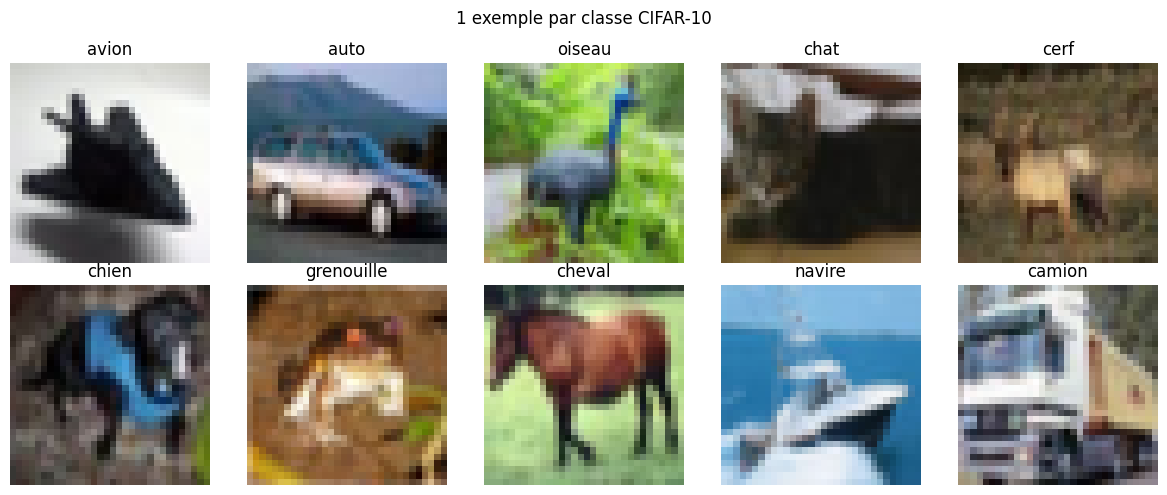

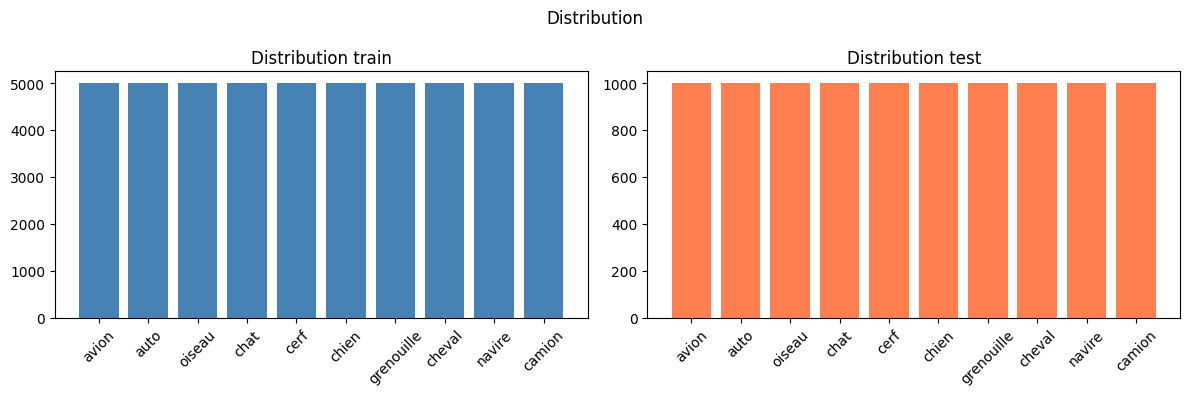

I0000 00:00:1775935380.446871   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775935380.449024   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775935380.450832   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775935380.531713   41053 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [1]:
import os
import sys
import gc
import numpy as np

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)    # suppress absl INFO/WARNING

import tensorflow as tf
tf.get_logger().setLevel('ERROR')                  # suppress TF Python-level logs

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow import keras
from tensorflow.keras import layers, applications

import tensorflow_datasets as tfds
from tensorflow_datasets.image_classification import cifar10_1

sys.path.insert(0, "Devoir partie 2/code")
from visualization import (
    image_sample_by_class,
    distribution,
    confusion_matrices,
    classification_error_samples,
    error_confidence,
    learning_curve
    )


print(sys.executable)
# sys.executable = "./scripts/tf_gpu_env.fish
print("LD_LIBRARY_PATH contains nvidia:", "site-packages/nvidia" in os.environ.get("LD_LIBRARY_PATH",""))

USE_GPU = True
CLASS_NAMES = ['avion','auto','oiseau','chat','cerf',
               'chien','grenouille','cheval','navire','camion']
               
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if gpus and USE_GPU:
    tf.config.set_visible_devices(gpus[0], "GPU")

    # Set memory growth If you want to use the local GPU IN case of desktop performance issues
    # tf.config.experimental.set_memory_growth(gpus[0], True)
    
else:
    print("No GPU detected by TensorFlow. CPU fallback.")


# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images
# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

# Exemples d'images CIFAR-10 par classe
image_sample_by_class(x_train, y_train)
# Distribution des classes (train + test)
distribution(y_train, y_test)

### CIFAR-10.1 pour validation externe

ds = tfds.load('cifar10_1', split='test', as_supervised=True)

x_ext = np.array([img.numpy() for img, _ in ds]) / 255.0
y_ext = np.array([lbl.numpy() for _, lbl in ds]).reshape(-1, 1)
# Le reshape(-1, 1) sur les labels est pour garder la même forme que y_test de CIFAR-10 (qui est (N, 1) avec sparse_categorical_crossentropy).



Epoch 1/100
  25/1563 [..............................] - ETA: 6s - loss: 2.3871 - accuracy: 0.1437

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 9s 5ms/step - loss: 1.3288 - accuracy: 0.5371 - val_loss: 1.0646 - val_accuracy: 0.6320 - lr: 0.0010
Epoch 2/100
1563/1563 [==============================] - 8s 5ms/step - loss: 1.0858 - accuracy: 0.6216 - val_loss: 0.9836 - val_accuracy: 0.6603 - lr: 0.0010
Epoch 3/100
1563/1563 [==============================] - 8s 5ms/step - loss: 1.0193 - accuracy: 0.6476 - val_loss: 0.9460 - val_accuracy: 0.6738 - lr: 0.0010
Epoch 4/100
1563/1563 [==============================] - 8s 5ms/step - loss: 0.9848 - accuracy: 0.6576 - val_loss: 0.9119 - val_accuracy: 0.6814 - lr: 0.0010
Epoch 5/100
1563/1563 [==============================] - 8s 5ms/step - loss: 0.9600 - accuracy: 0.6670 - val_loss: 0.9026 - val_accuracy: 0.6840 - lr: 0.0010
Epoch 6/100
1563/1563 [==============================] - 8s 5ms/step - loss: 0.9394 - accuracy: 0.6741 - val_loss: 0.8951 - val_accuracy: 0.6865 - lr: 0.0010
Epoch 7/100
1563/1563 [==============================] - 8s 5ms/

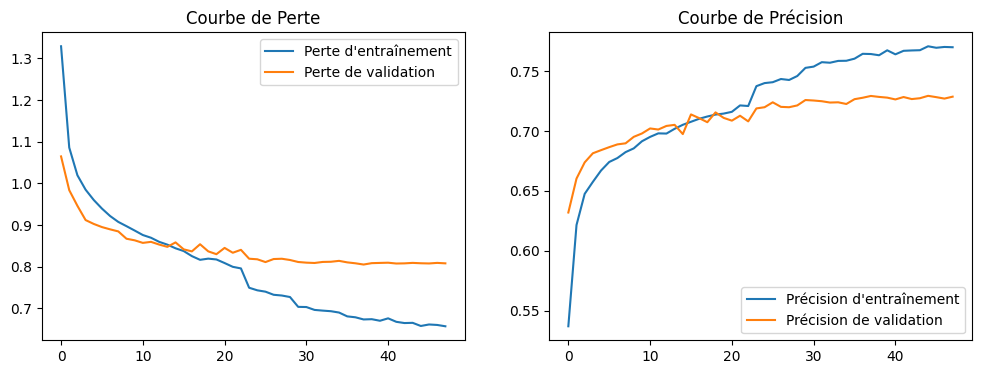

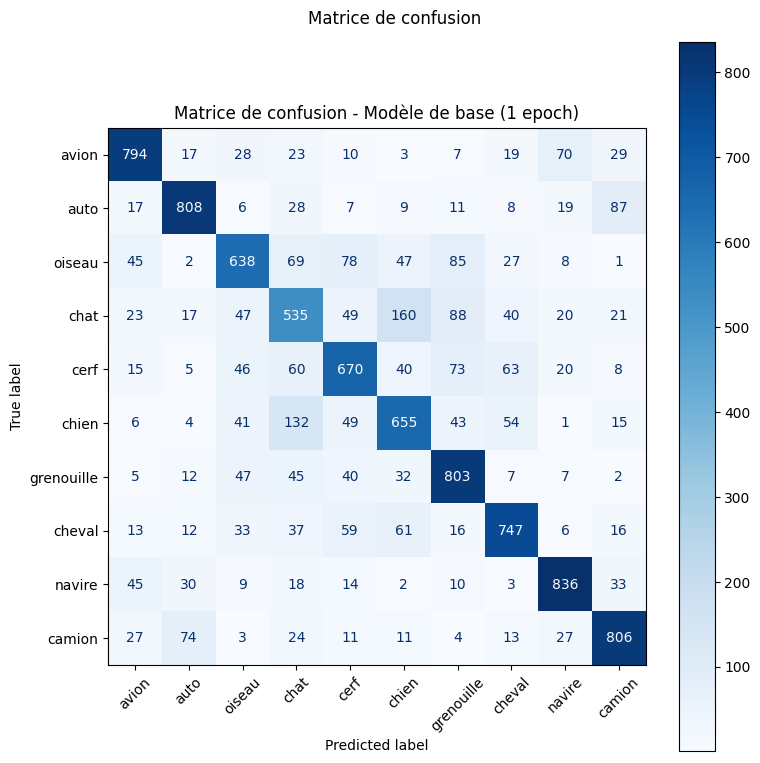

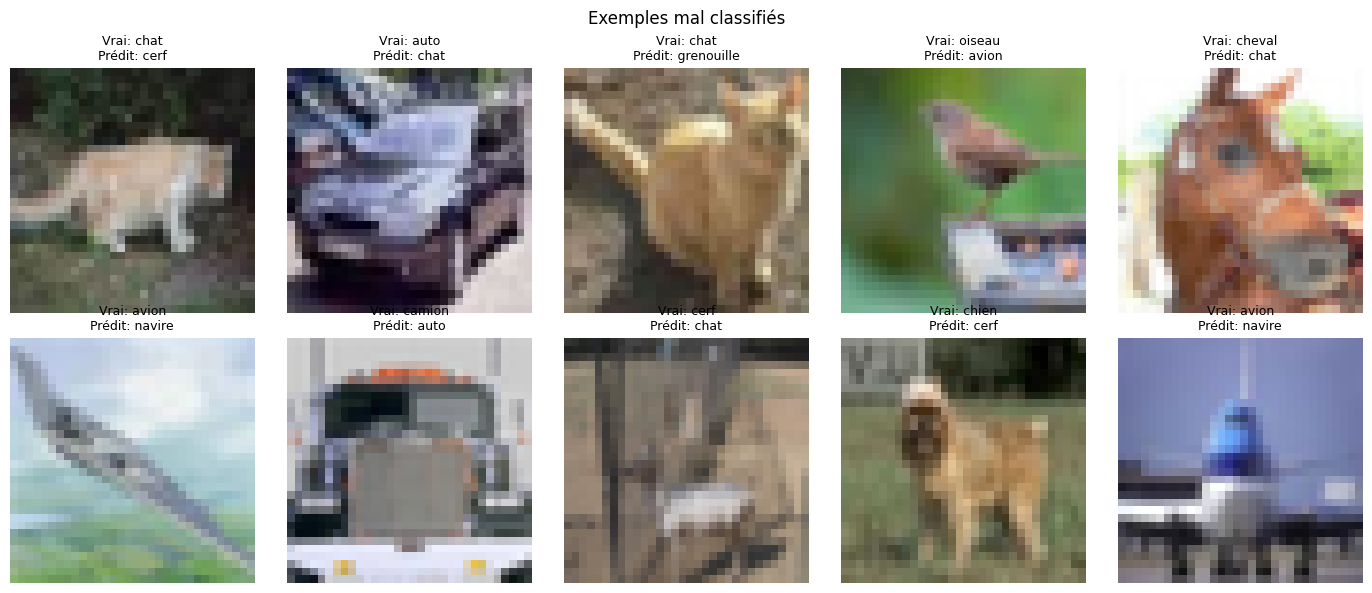

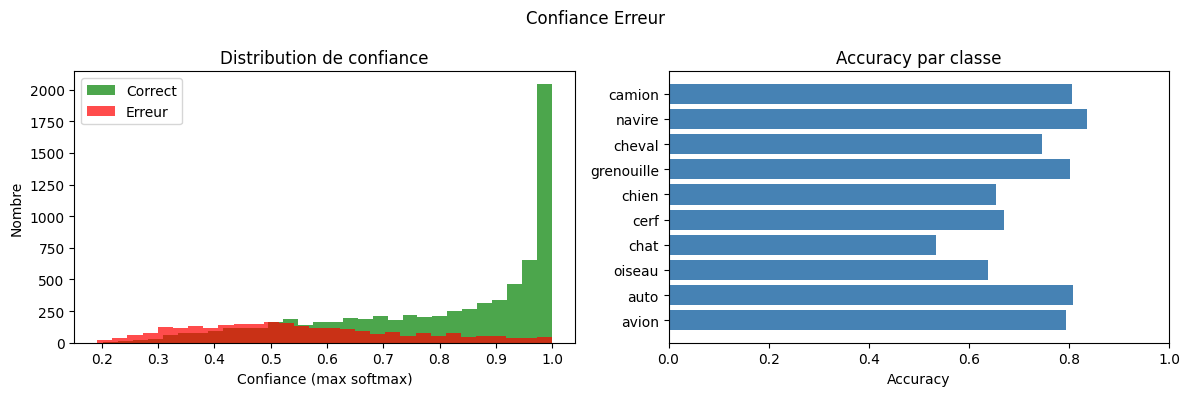

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.2916 - accuracy: 0.5893 - 321ms/epoch - 5ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.5893
33/64 [==============>...............] - ETA: 0s

W0000 00:00:1775937212.552211   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552280   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552315   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552364   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552409   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552452   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552493   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552544   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775937212.552582   41202 gp

64/64 [==============================] - 0s 3ms/step


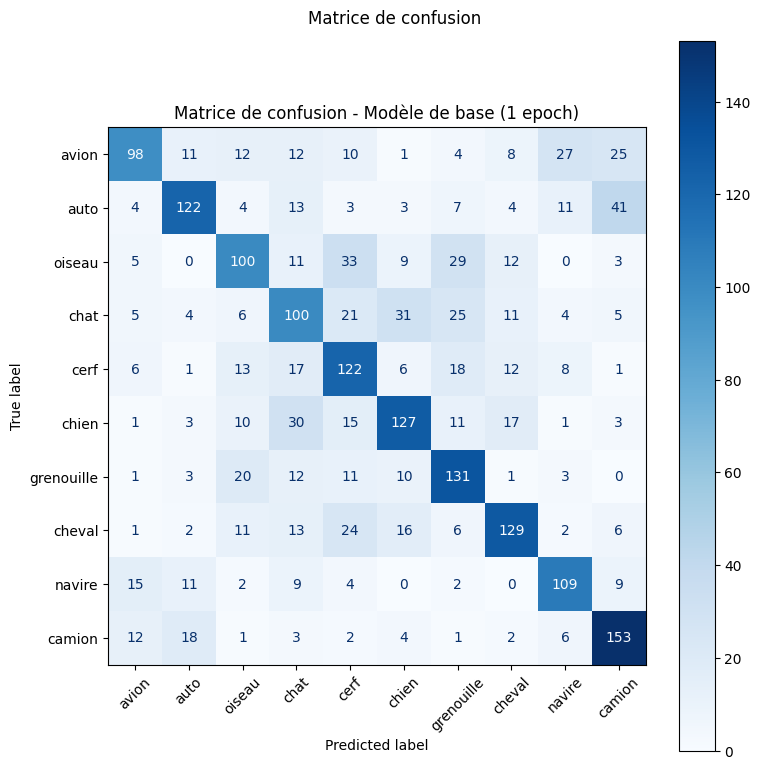

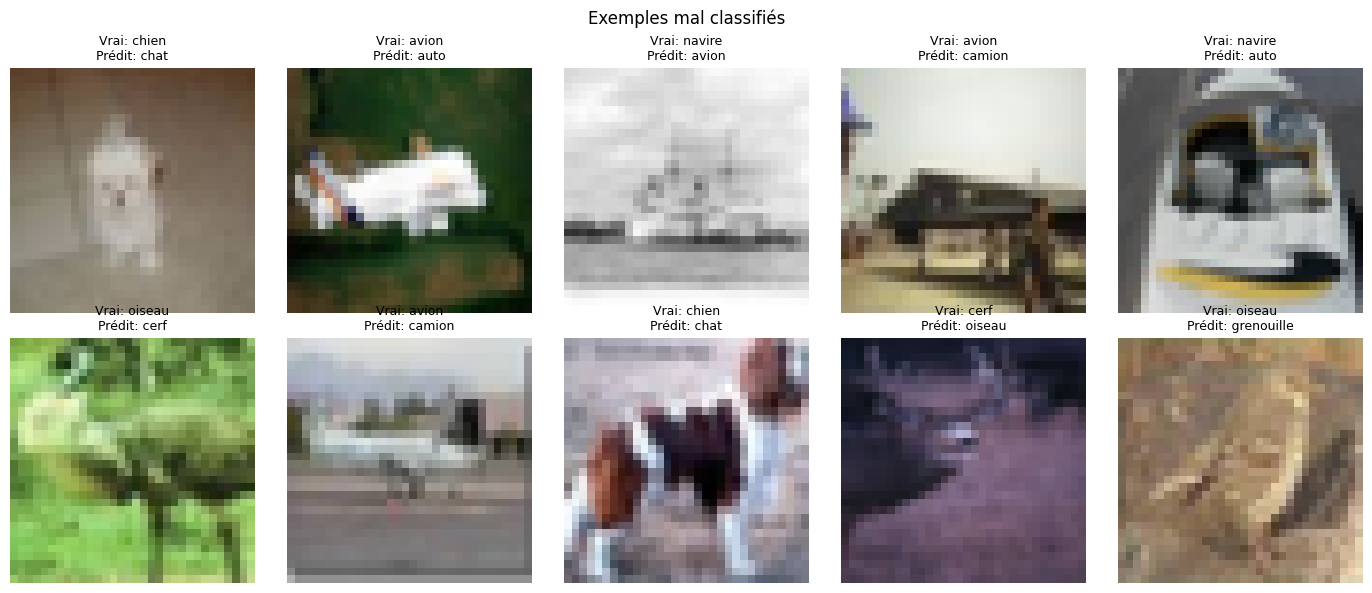

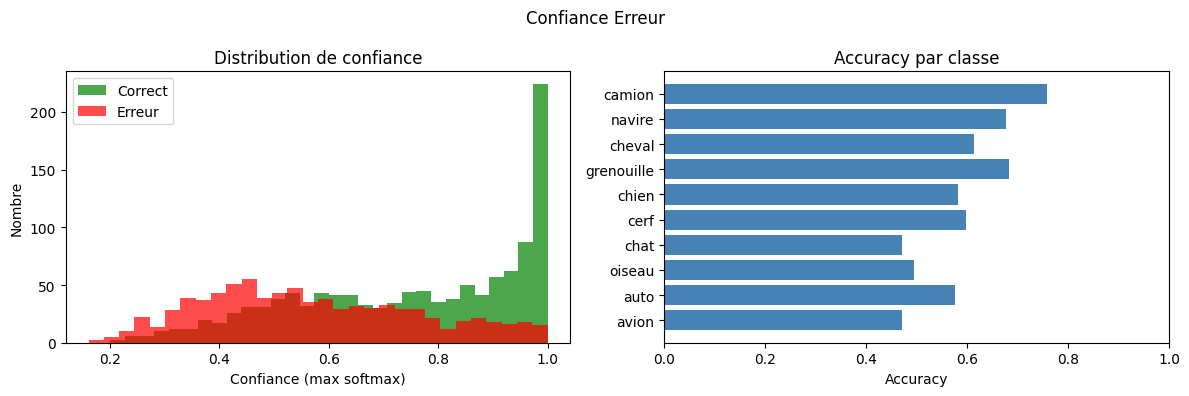

100177

In [10]:
# Question pour expérimenter l'Apprentissage par Transfert Avec quelques modifications

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(96, 96),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = transfer_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = transfer_model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = transfer_model.predict(x_ext).argmax(axis=1)
y_proba_ext = transfer_model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, transfer_model
gc.collect()

Epoch 1/100


W0000 00:00:1775935381.497091   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.502957   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.503017   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.503961   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.504024   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.504085   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.507563   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.507638   41197 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.507872   41197 gp

   1/1563 [..............................] - ETA: 17:25 - loss: 2.3197 - accuracy: 0.0625

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775935381.728831   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.728914   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.728955   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.729323   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.729371   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.731086   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935381.731150   41196 gpu_timer.cc:114] Skipping

 110/1563 [=>............................] - ETA: 2s - loss: 2.1448 - accuracy: 0.1878

...

1563/1563 [==============================] - 2s 1ms/step - loss: 0.4609 - accuracy: 0.8377 - val_loss: 0.9147 - val_accuracy: 0.7133
Epoch 12/100


W0000 00:00:1775935400.401814   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.401870   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.401906   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.401939   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.401971   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.402005   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.402044   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.402094   41196 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935400.402153   41196 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 0.4283 - accuracy: 0.8462 - val_loss: 0.9242 - val_accuracy: 0.7219
Epoch 13/100
   1/1563 [..............................] - ETA: 2s - loss: 0.3323 - accuracy: 0.8125

W0000 00:00:1775935402.198196   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198252   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198288   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198321   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198353   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198389   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198426   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198481   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935402.198532   41199 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 0.3971 - accuracy: 0.8576 - val_loss: 0.9839 - val_accuracy: 0.7082
Epoch 14/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.3594 - accuracy: 0.8706 - val_loss: 1.0551 - val_accuracy: 0.7075
Epoch 15/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.3285 - accuracy: 0.8823 - val_loss: 1.0999 - val_accuracy: 0.7131
Epoch 16/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.3032 - accuracy: 0.8915 - val_loss: 1.1030 - val_accuracy: 0.7089
313/313 - 0s - loss: 0.8518 - accuracy: 0.7116 - 159ms/epoch - 508us/step
Précision sur l’ensemble de test : 0.7116
313/313 [==============================] - 0s 367us/step


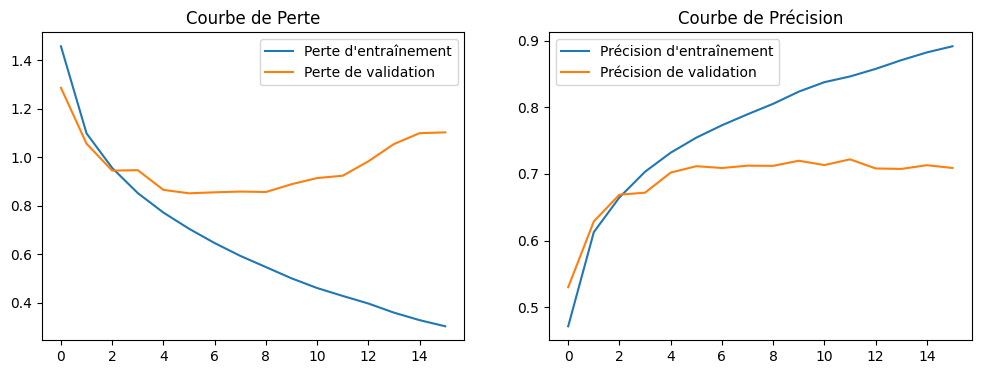

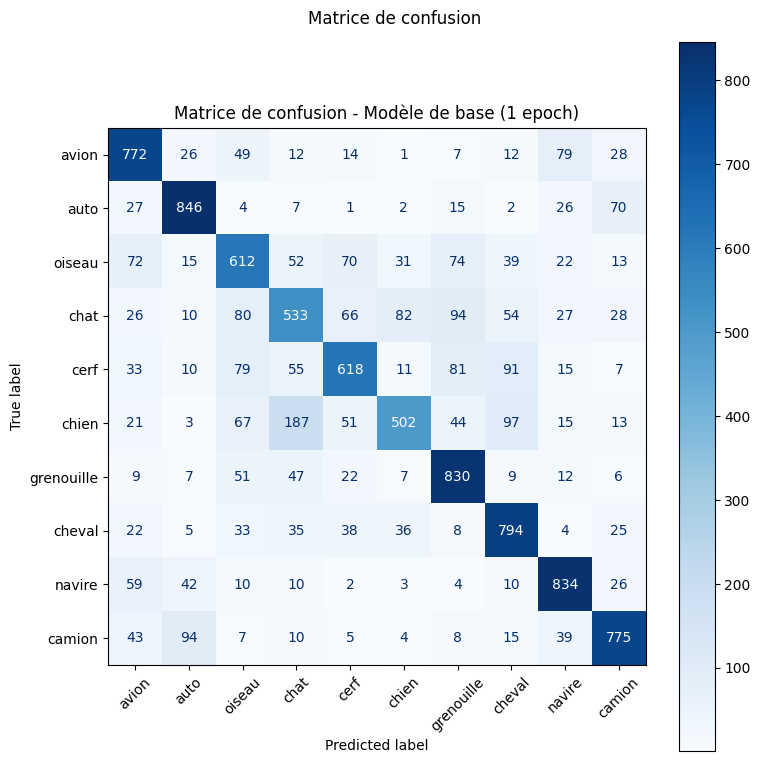

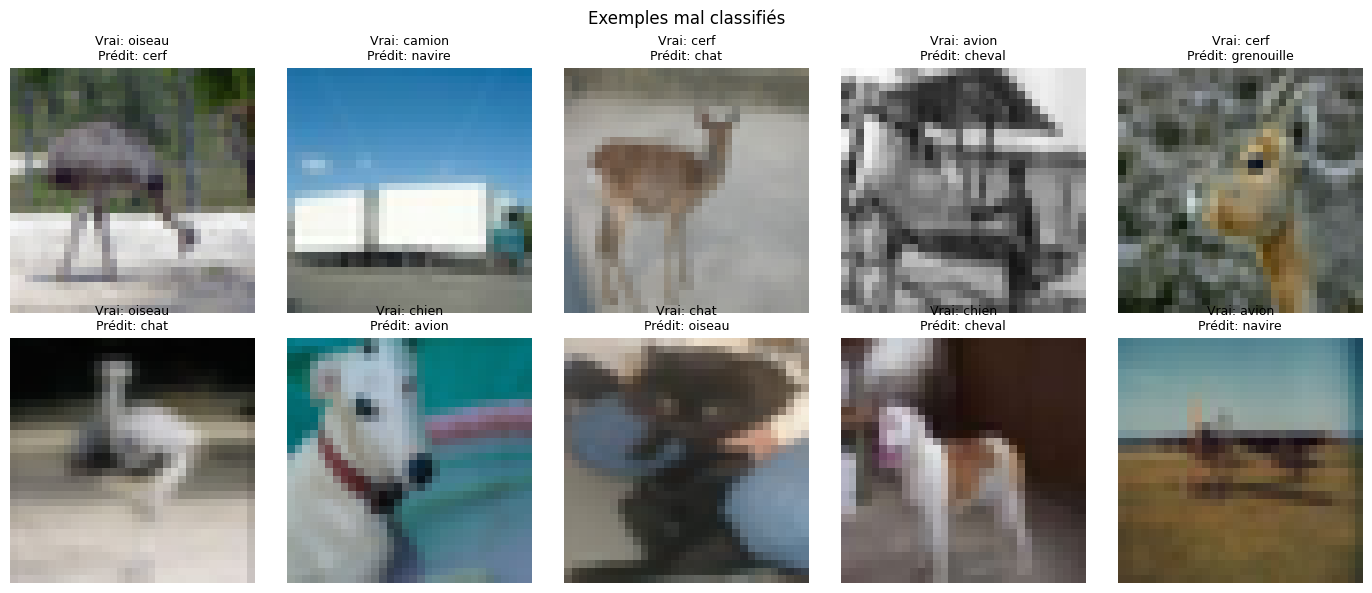

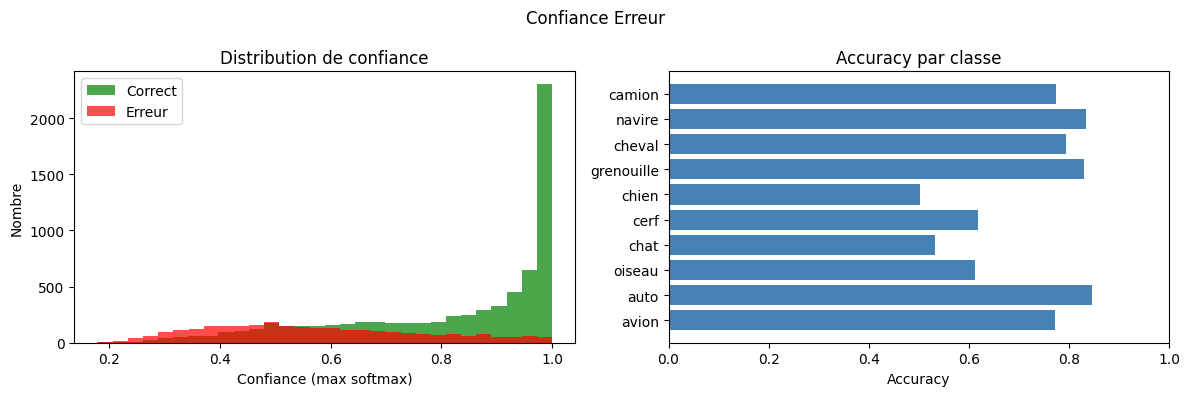

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.3150 - accuracy: 0.5631 - 82ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.5631
64/64 [==============================] - 0s 356us/step


W0000 00:00:1775935410.745310   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745357   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745376   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745396   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745419   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745440   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745483   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745508   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935410.745535   41189 gp

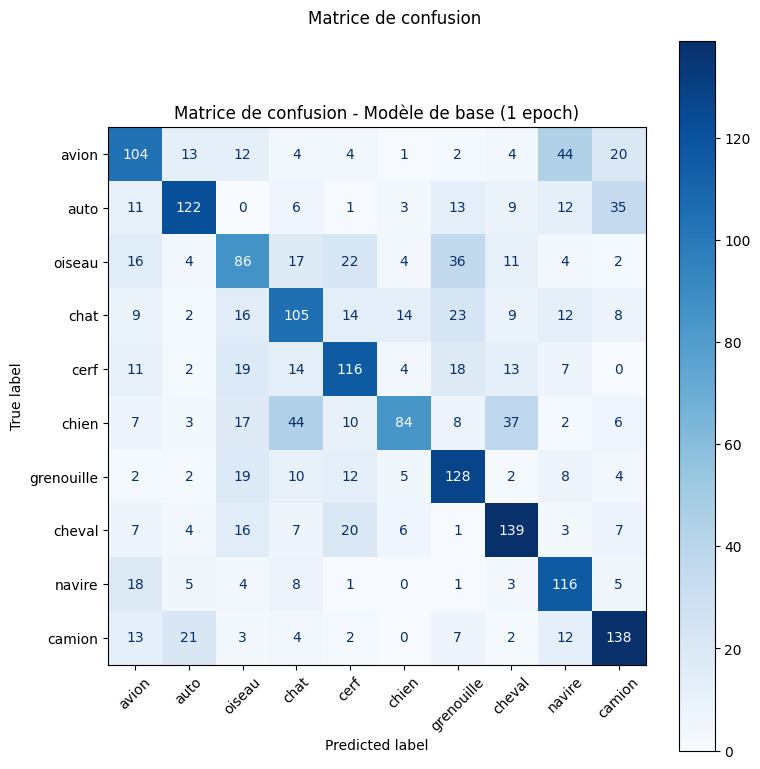

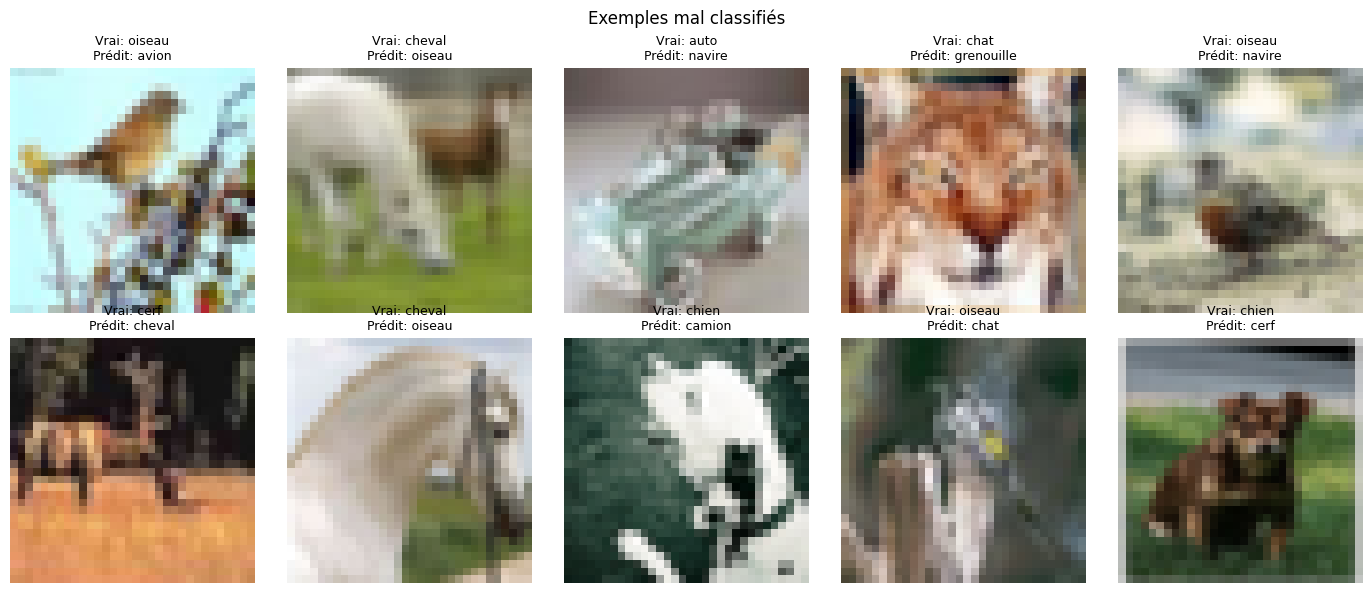

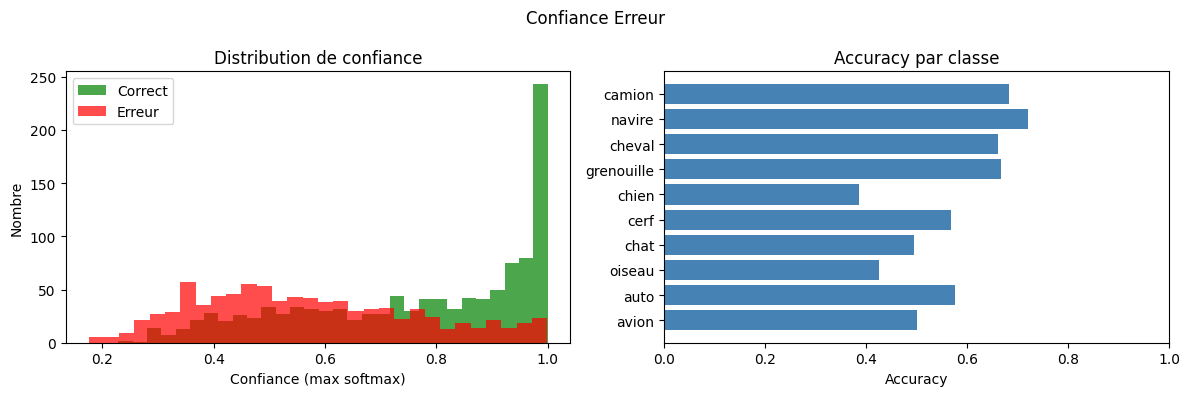

31658

In [2]:
# Définition du modèle CNN de base
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

   1/1563 [..............................] - ETA: 24:13 - loss: 3.2803 - accuracy: 0.2188

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775935412.602666   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935412.602756   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935412.602794   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

1550/1563 [============================>.] - ETA: 0s - loss: 1.7051 - accuracy: 0.3718

W0000 00:00:1775935414.403602   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403662   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403696   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403726   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403766   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403801   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403848   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403878   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935414.403953   41202 gp

1563/1563 [==============================] - 3s 1ms/step - loss: 1.7022 - accuracy: 0.3726 - val_loss: 1.4846 - val_accuracy: 0.4599
Epoch 2/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.3872 - accuracy: 0.5000 - val_loss: 1.1452 - val_accuracy: 0.5979
Epoch 3/20
   1/1563 [..............................] - ETA: 2s - loss: 0.9778 - accuracy: 0.6562

W0000 00:00:1775935416.348214   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348270   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348305   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348333   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348375   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348410   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348456   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348487   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935416.348562   41198 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.2551 - accuracy: 0.5563 - val_loss: 1.0957 - val_accuracy: 0.6082
Epoch 4/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1861 - accuracy: 0.5833 - val_loss: 1.0481 - val_accuracy: 0.6178
Epoch 5/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1163 - accuracy: 0.6119 - val_loss: 0.9864 - val_accuracy: 0.6484
Epoch 6/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0762 - accuracy: 0.6284 - val_loss: 0.9241 - val_accuracy: 0.6832
Epoch 7/20
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0301 - accuracy: 0.6451 - val_loss: 0.8885 - val_accuracy: 0.6962
Epoch 8/20
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9993 - accuracy: 0.6549 - val_loss: 0.9390 - val_accuracy: 0.6700
Epoch 9/20
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9734 - accuracy: 0.6656 - val_loss: 0.8301 - val_accuracy: 0.7168
Epo

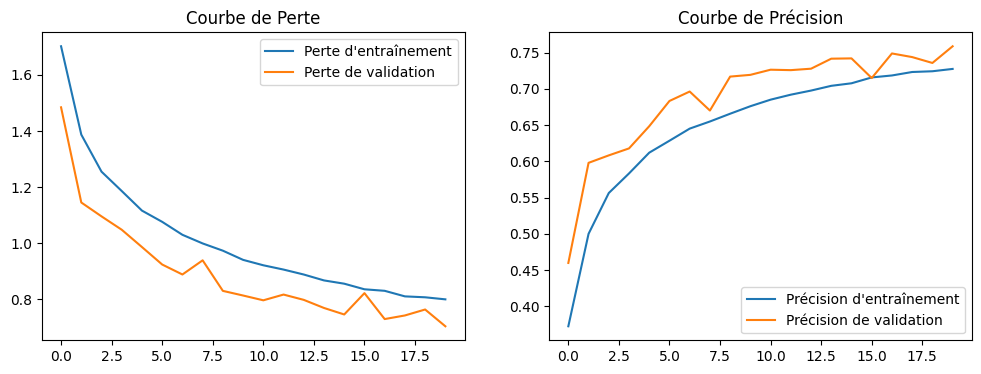

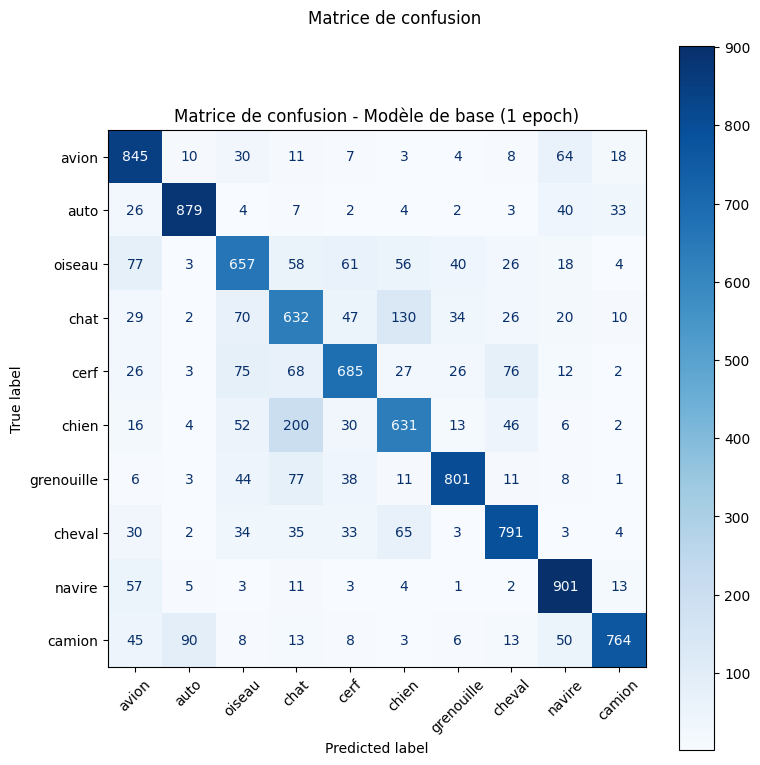

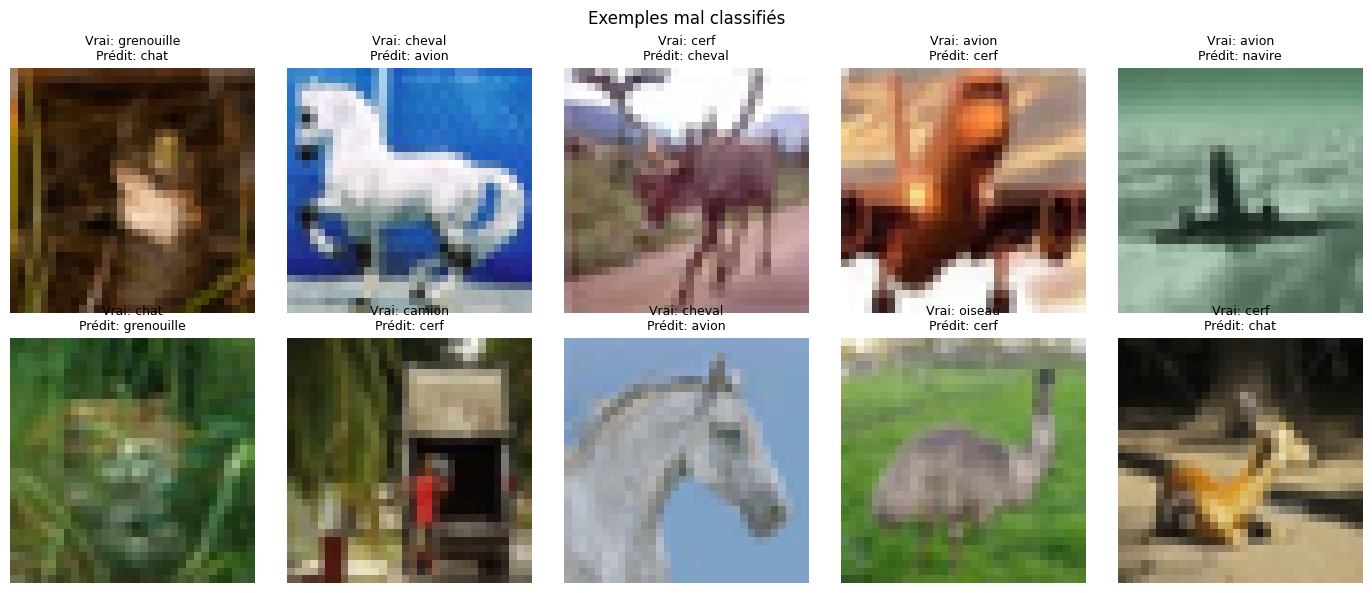

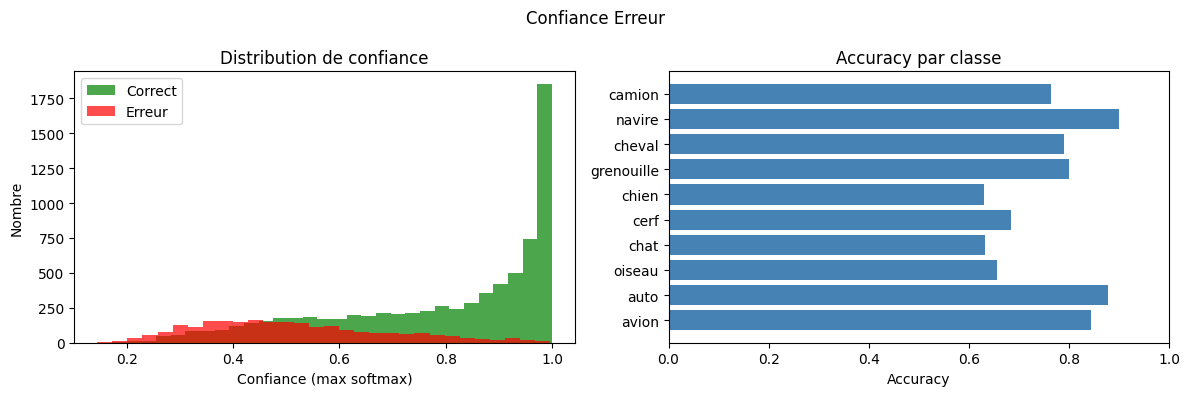

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 1.0881 - accuracy: 0.6150 - 82ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6150
64/64 [==============================] - 0s 388us/step


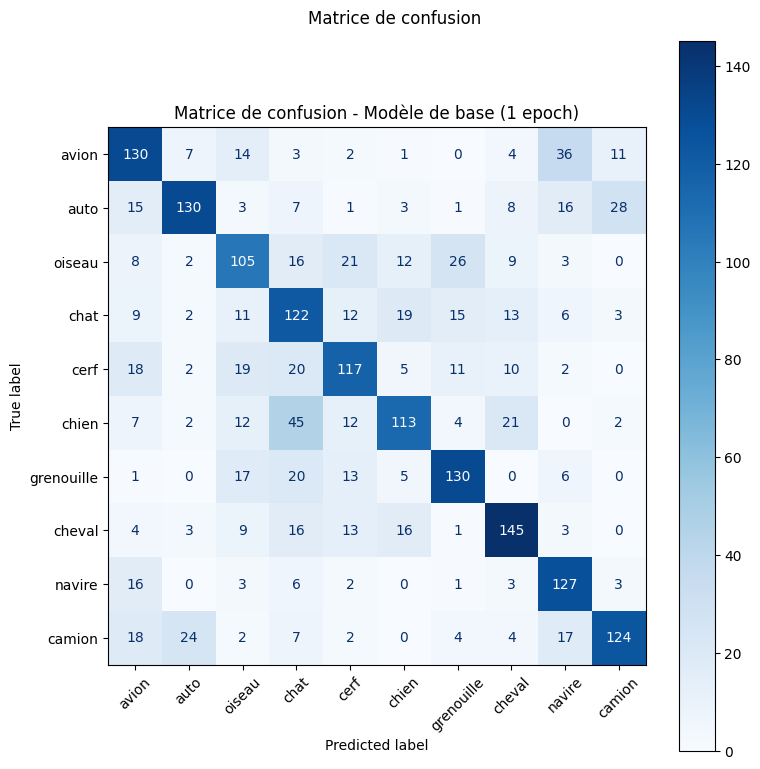

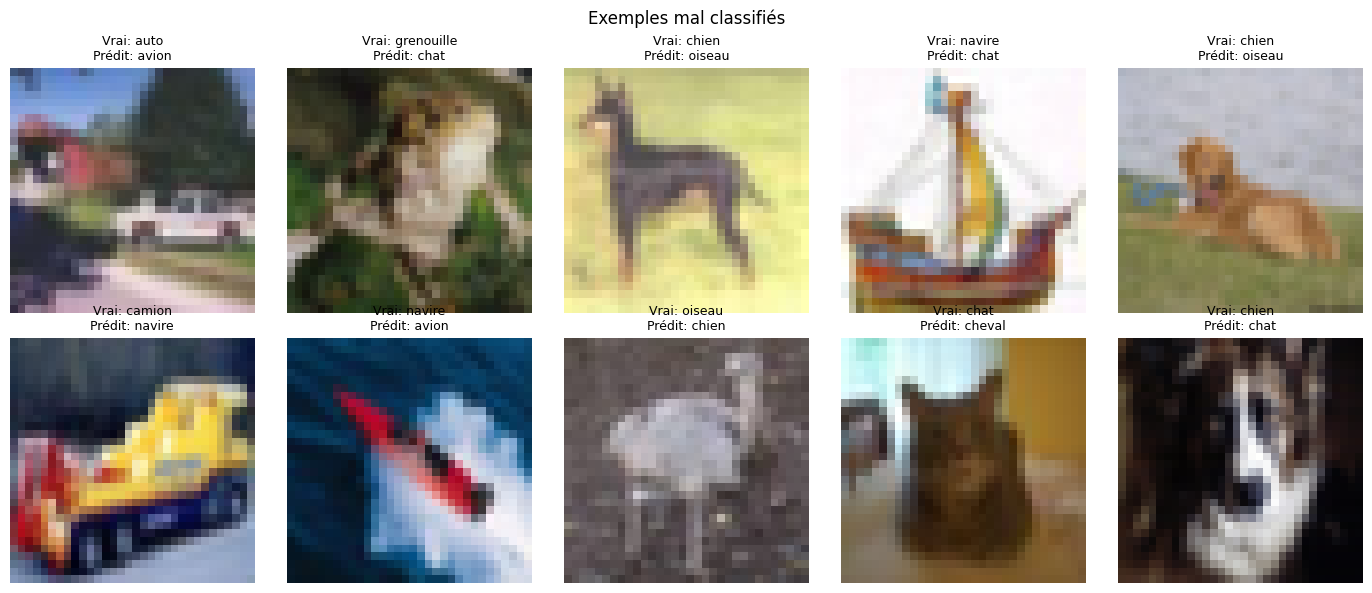

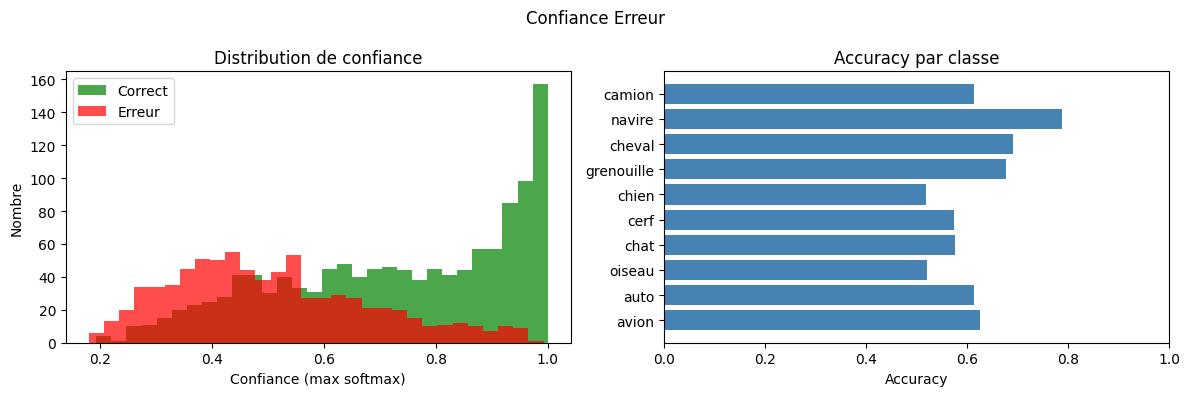

98763

In [3]:
# Définition du modèle CNN
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), #Ajout
    layers.Dropout(0.5), #Ajout
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


W0000 00:00:1775935451.490174   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.491810   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.491865   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.491906   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.491931   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.491989   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.492044   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.492081   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.492119   41192 gp

 124/1563 [=>............................] - ETA: 1s - loss: 2.6942 - accuracy: 0.1822

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775935451.716140   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.716193   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.716217   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.716254   41198 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935451.716278   41198 gpu_timer.cc:114] Skipping the delay kernel, measu

1533/1563 [============================>.] - ETA: 0s - loss: 1.8184 - accuracy: 0.3465

...

1563/1563 [==============================] - 2s 1ms/step - loss: 1.2292 - accuracy: 0.5674 - val_loss: 1.0848 - val_accuracy: 0.6107
Epoch 5/100
   1/1563 [..............................] - ETA: 2s - loss: 1.3671 - accuracy: 0.5312

W0000 00:00:1775935459.144830   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.144879   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.144909   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.144937   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.144963   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.144993   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.145033   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.145071   41201 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935459.145104   41201 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.1679 - accuracy: 0.5899 - val_loss: 1.0514 - val_accuracy: 0.6266
Epoch 6/100
   1/1563 [..............................] - ETA: 2s - loss: 1.2197 - accuracy: 0.5000

W0000 00:00:1775935461.022511   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022560   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022588   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022617   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022642   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022672   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022709   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022744   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935461.022775   41199 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.1162 - accuracy: 0.6079 - val_loss: 0.9649 - val_accuracy: 0.6562
Epoch 7/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0787 - accuracy: 0.6253 - val_loss: 1.1086 - val_accuracy: 0.6028
Epoch 8/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0460 - accuracy: 0.6359 - val_loss: 0.9113 - val_accuracy: 0.6857
Epoch 9/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0101 - accuracy: 0.6466 - val_loss: 0.8672 - val_accuracy: 0.6953
Epoch 10/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9971 - accuracy: 0.6538 - val_loss: 1.0926 - val_accuracy: 0.6168
Epoch 11/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9723 - accuracy: 0.6634 - val_loss: 0.9332 - val_accuracy: 0.6707
Epoch 12/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9608 - accuracy: 0.6664 - val_loss: 0.9394 - val_accuracy: 0

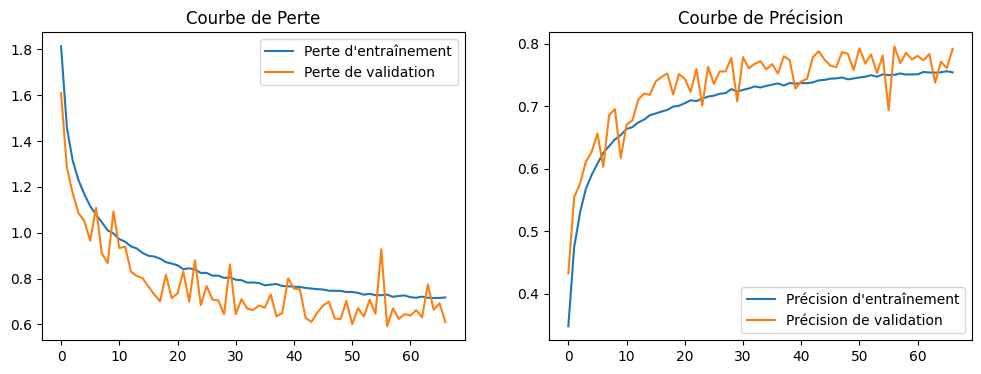

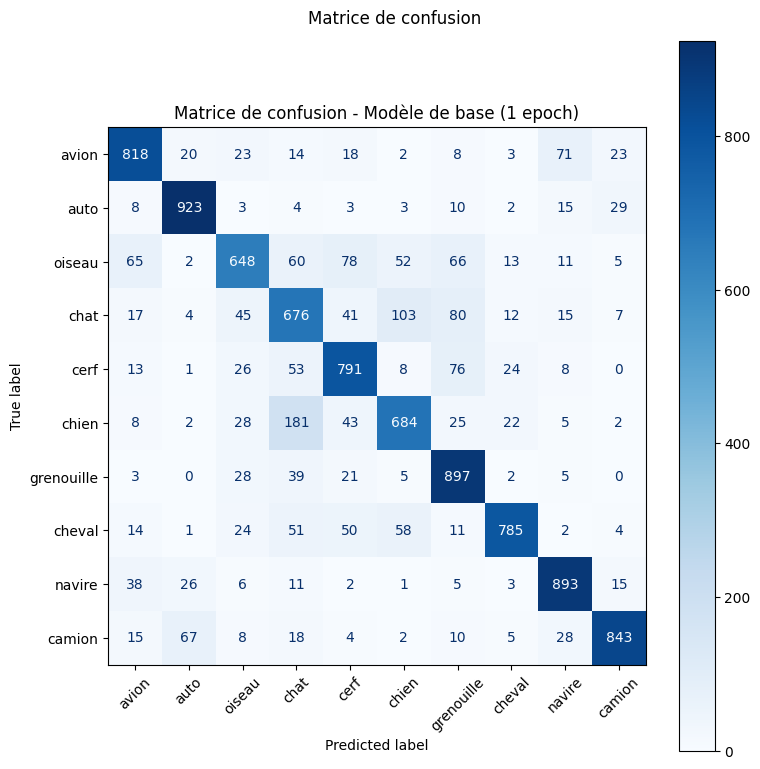

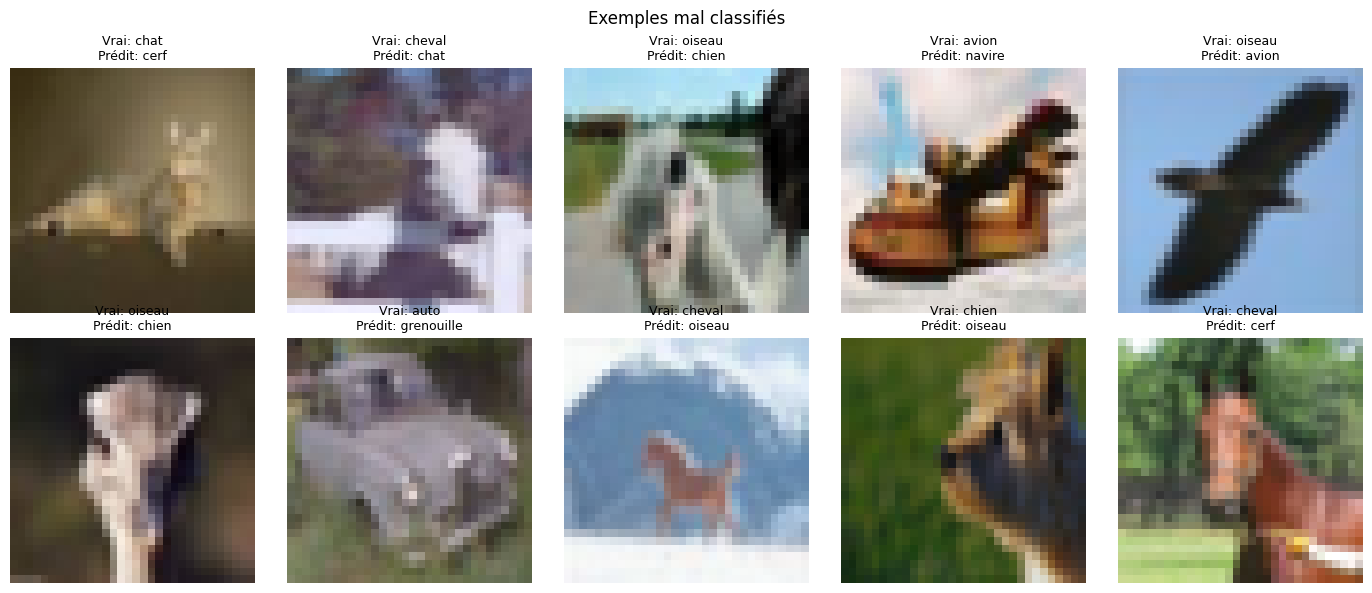

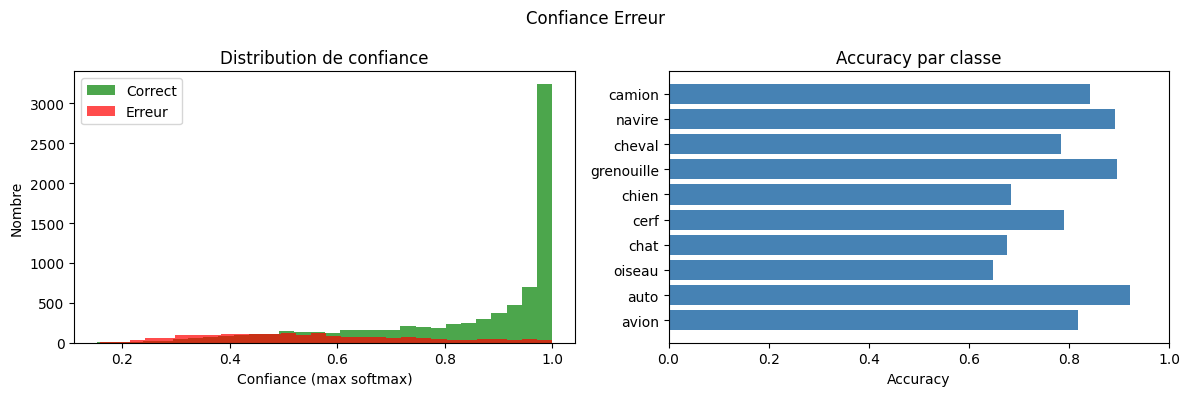

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.9945 - accuracy: 0.6556 - 87ms/epoch - 1ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6556
64/64 [==============================] - 0s 543us/step


W0000 00:00:1775935578.067729   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067768   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067787   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067805   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067827   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067854   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067876   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067907   41192 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935578.067945   41192 gp

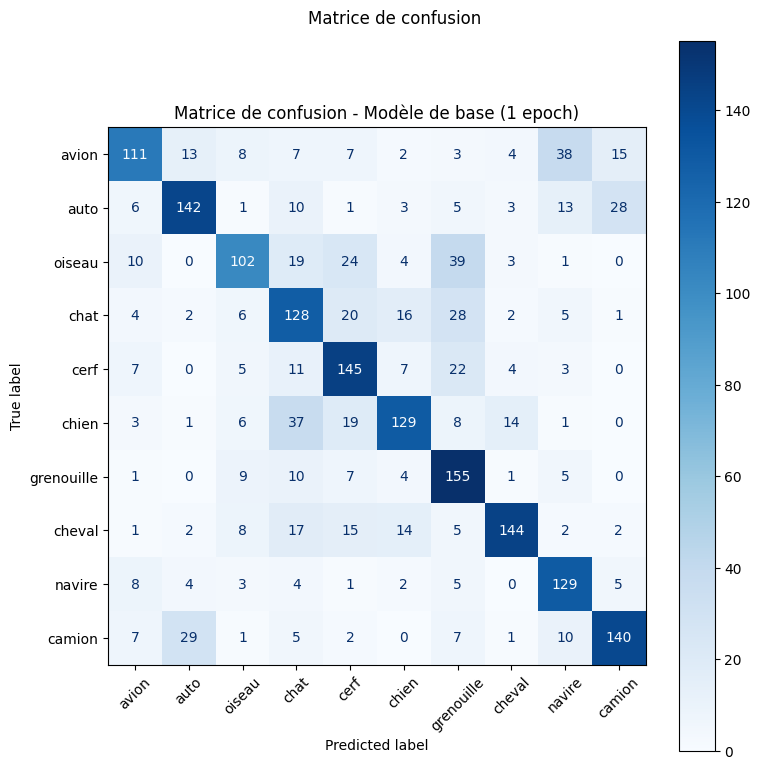

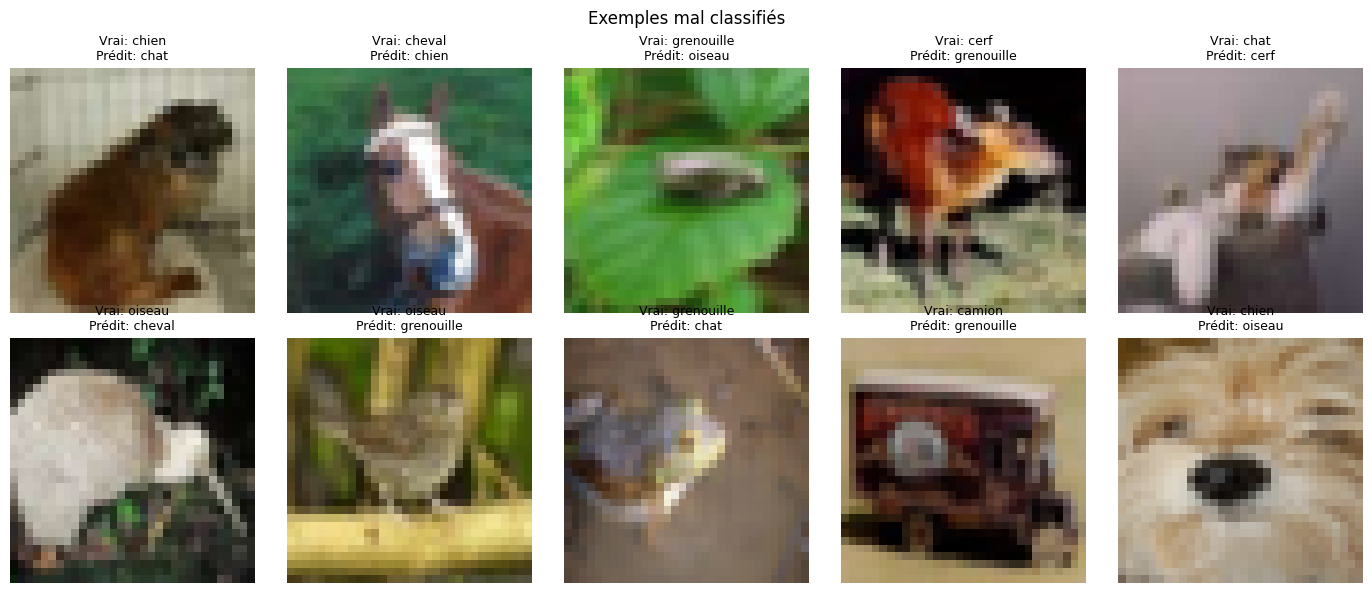

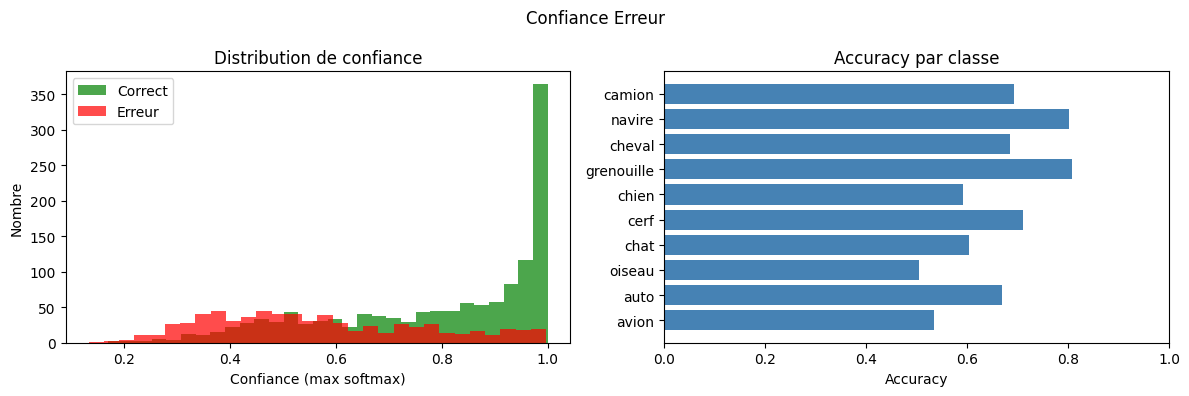

98459

In [4]:
# Définition du modèle CNN avec 
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


   1/1563 [..............................] - ETA: 11:18 - loss: 5.1220 - accuracy: 0.0312

W0000 00:00:1775935579.328648   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328712   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328738   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328778   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328804   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328828   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328878   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.328913   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935579.329047   41202 gp

1563/1563 [==============================] - ETA: 0s - loss: 2.0552 - accuracy: 0.2552

W0000 00:00:1775935581.311792   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311837   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311857   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311878   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311906   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311932   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.311954   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.312005   41199 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935581.312045   41199 gp

1563/1563 [==============================] - 3s 1ms/step - loss: 2.0552 - accuracy: 0.2552 - val_loss: 1.9647 - val_accuracy: 0.2807
Epoch 2/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.6879 - accuracy: 0.3928 - val_loss: 1.5262 - val_accuracy: 0.4382
Epoch 3/100
   1/1563 [..............................] - ETA: 2s - loss: 1.6073 - accuracy: 0.3438

W0000 00:00:1775935583.409469   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409530   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409566   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409627   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409668   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409716   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409746   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409779   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935583.409855   41189 gp

1563/1563 [==============================] - 2s 1ms/step - loss: 1.4246 - accuracy: 0.4908 - val_loss: 1.1497 - val_accuracy: 0.5886
Epoch 4/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.2722 - accuracy: 0.5491 - val_loss: 1.4625 - val_accuracy: 0.5031
Epoch 5/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1714 - accuracy: 0.5911 - val_loss: 1.1750 - val_accuracy: 0.5777
Epoch 6/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.1140 - accuracy: 0.6121 - val_loss: 1.0533 - val_accuracy: 0.6148
Epoch 7/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0691 - accuracy: 0.6283 - val_loss: 1.2795 - val_accuracy: 0.5707
Epoch 8/100
1563/1563 [==============================] - 2s 1ms/step - loss: 1.0279 - accuracy: 0.6452 - val_loss: 0.8566 - val_accuracy: 0.7044
Epoch 9/100
1563/1563 [==============================] - 2s 1ms/step - loss: 0.9936 - accuracy: 0.6560 - val_loss: 0.9644 - val_accuracy: 0.66

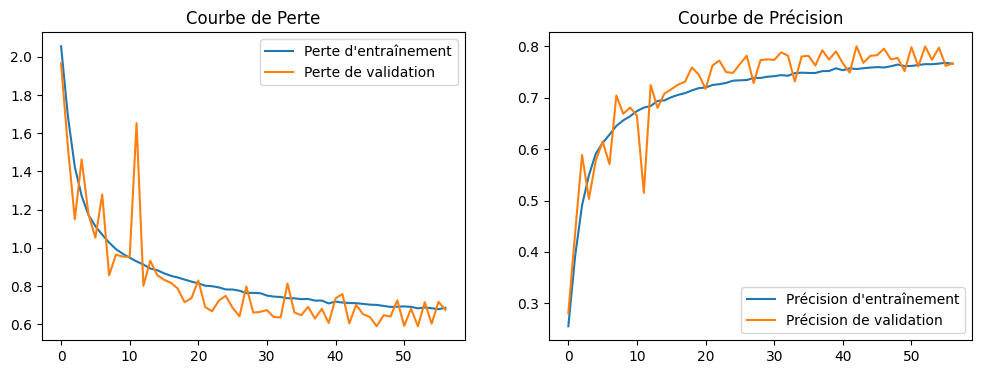

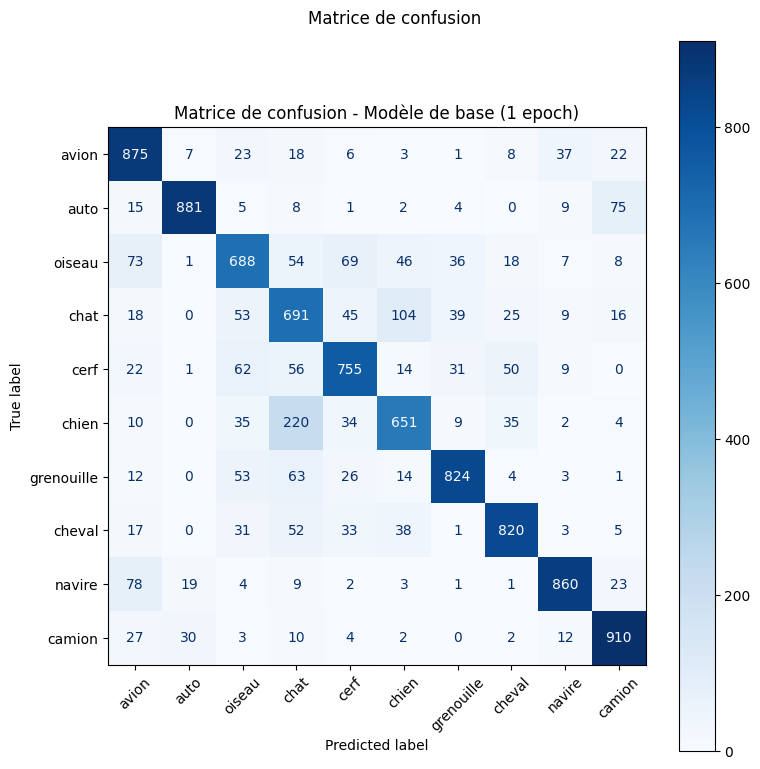

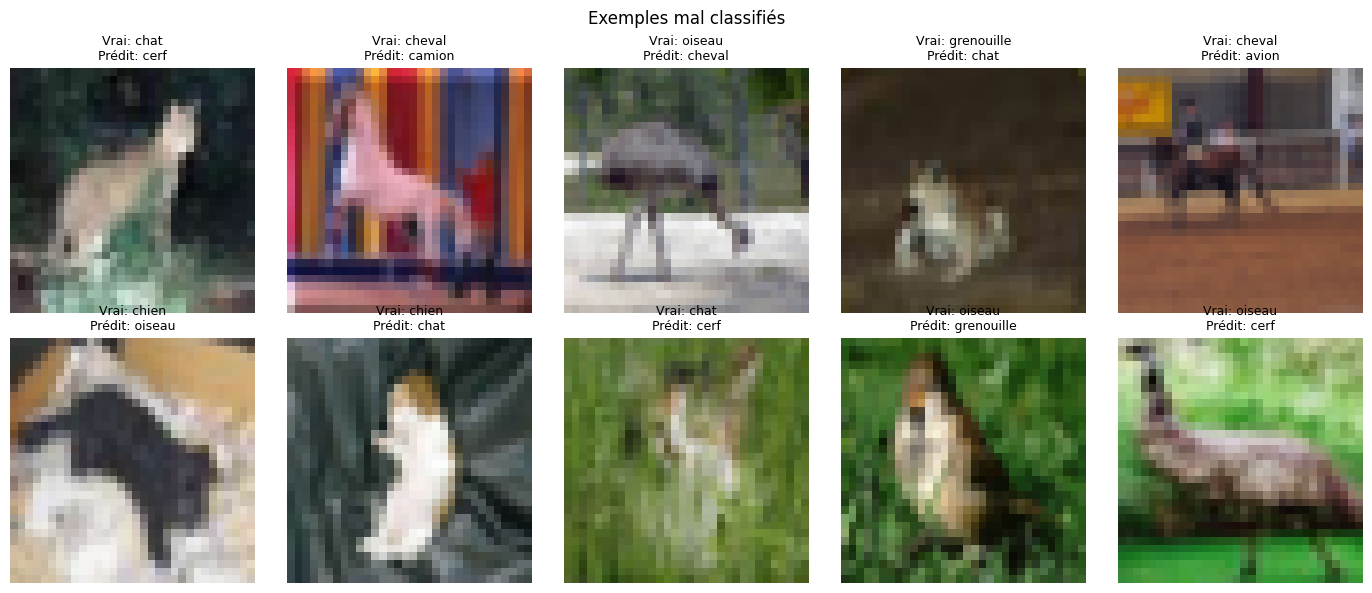

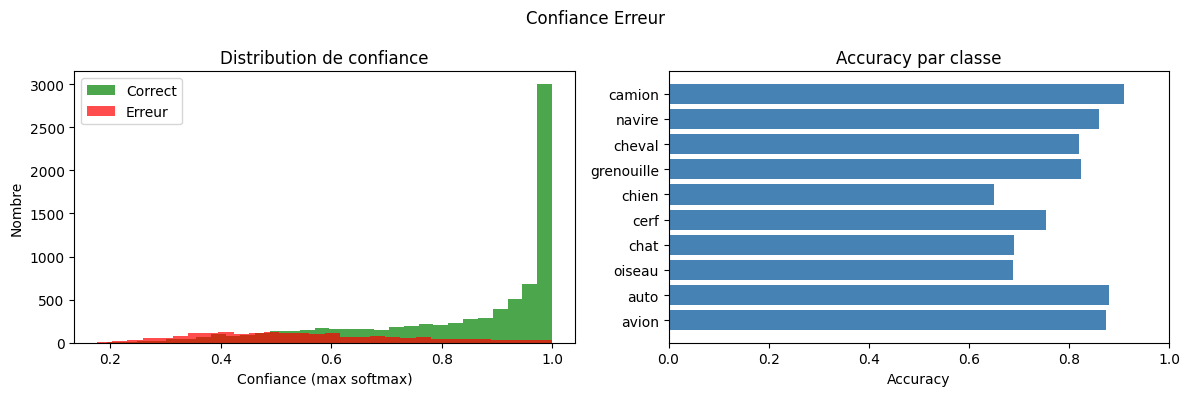

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.9771 - accuracy: 0.6739 - 122ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.6739
64/64 [==============================] - 0s 545us/step


W0000 00:00:1775935741.978901   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.978996   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.979170   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.979337   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.979637   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.980088   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.980111   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.980166   41200 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935741.980203   41200 gp

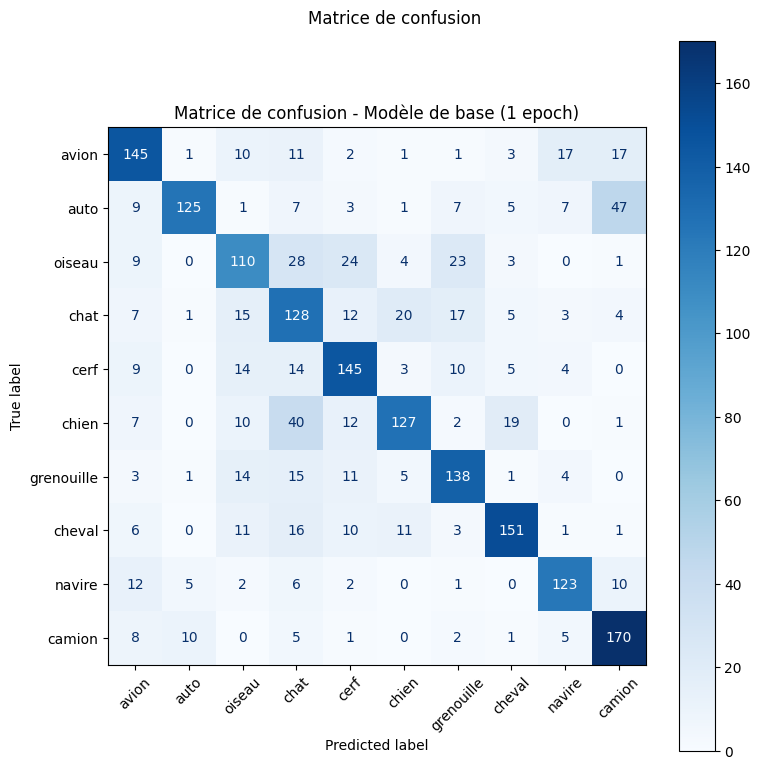

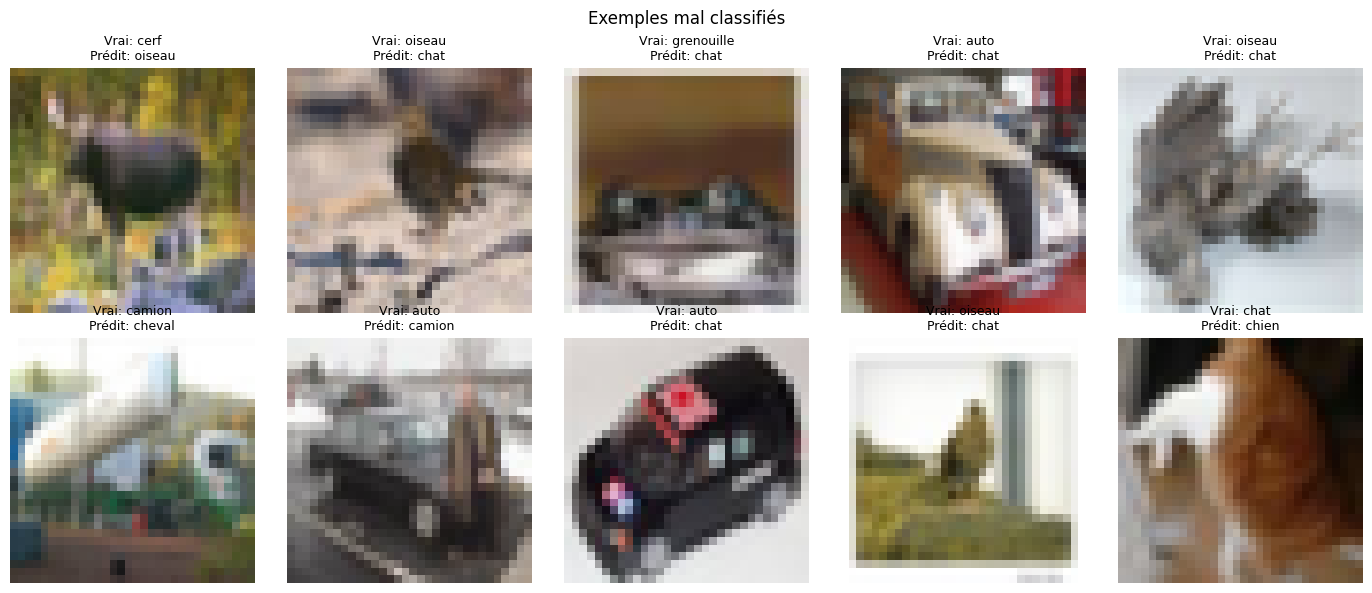

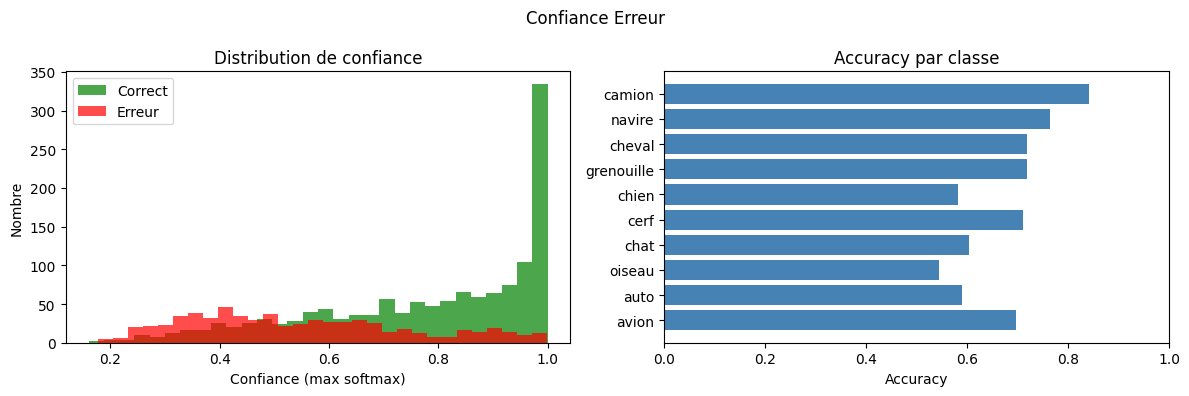

99014

In [5]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 15:51 - loss: 2.6025 - accuracy: 0.1875

W0000 00:00:1775935743.455246   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455358   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455815   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455853   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455888   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455930   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.455971   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.456014   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.456199   41189 gp

  86/1563 [>.............................] - ETA: 3s - loss: 2.3556 - accuracy: 0.2217

W0000 00:00:1775935743.656134   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.656189   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.656245   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.656297   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935743.656358   41189 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


1563/1563 [==============================] - ETA: 0s - loss: 1.5372 - accuracy: 0.4607

W0000 00:00:1775935747.226981   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227091   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227122   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227151   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227184   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227217   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227252   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227287   41202 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935747.227323   41202 gp

1563/1563 [==============================] - 5s 3ms/step - loss: 1.5372 - accuracy: 0.4607 - val_loss: 1.1428 - val_accuracy: 0.6102 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 4s 2ms/step - loss: 1.1028 - accuracy: 0.6259 - val_loss: 0.9015 - val_accuracy: 0.6990 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.9454 - accuracy: 0.6868 - val_loss: 0.7846 - val_accuracy: 0.7424 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 0.8519 - accuracy: 0.7174 - val_loss: 0.7095 - val_accuracy: 0.7689 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.7818 - accuracy: 0.7446 - val_loss: 0.7667 - val_accuracy: 0.7536 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.7311 - accuracy: 0.7644 - val_loss: 0.7428 - val_accuracy: 0.7596 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 3s 2ms/

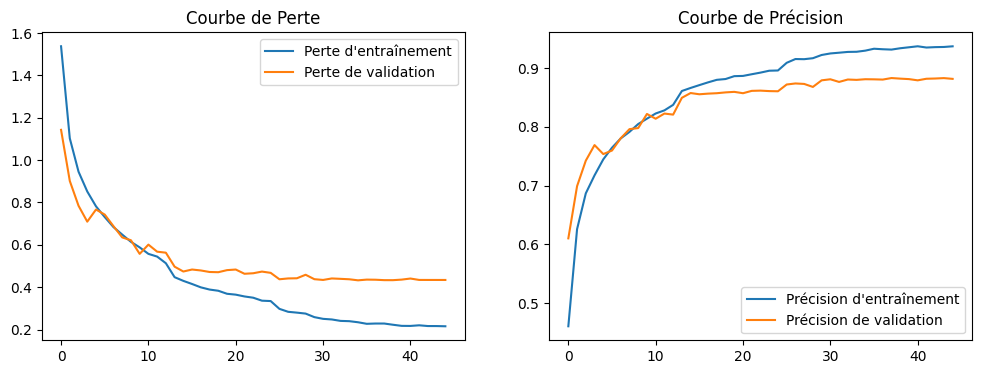

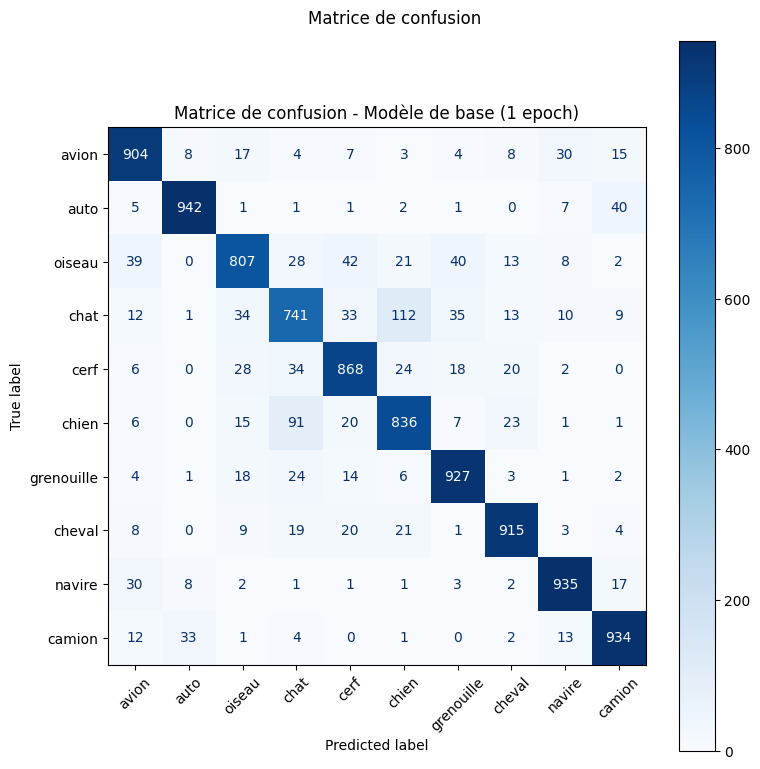

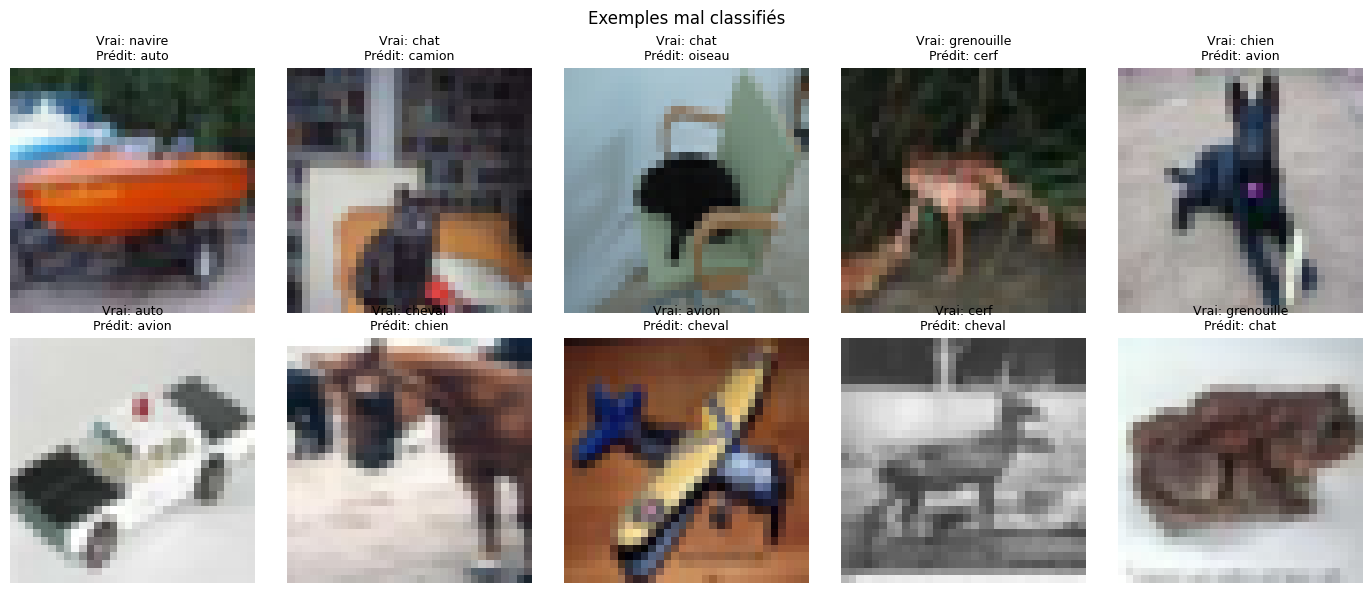

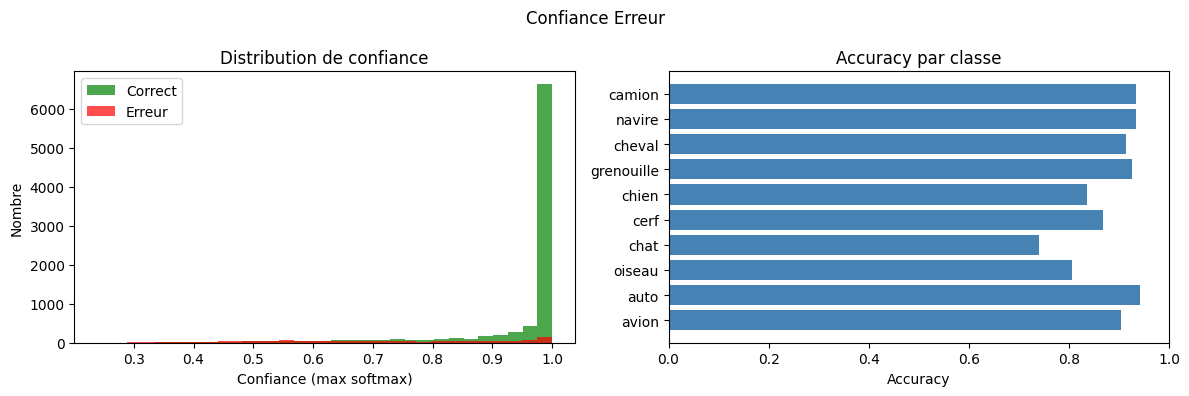

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8574 - accuracy: 0.7759 - 152ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7759
64/64 [==============================] - 0s 692us/step


W0000 00:00:1775935896.179234   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.179343   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.179483   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.179630   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.179768   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.179921   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.180064   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.180256   41195 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775935896.180645   41195 gp

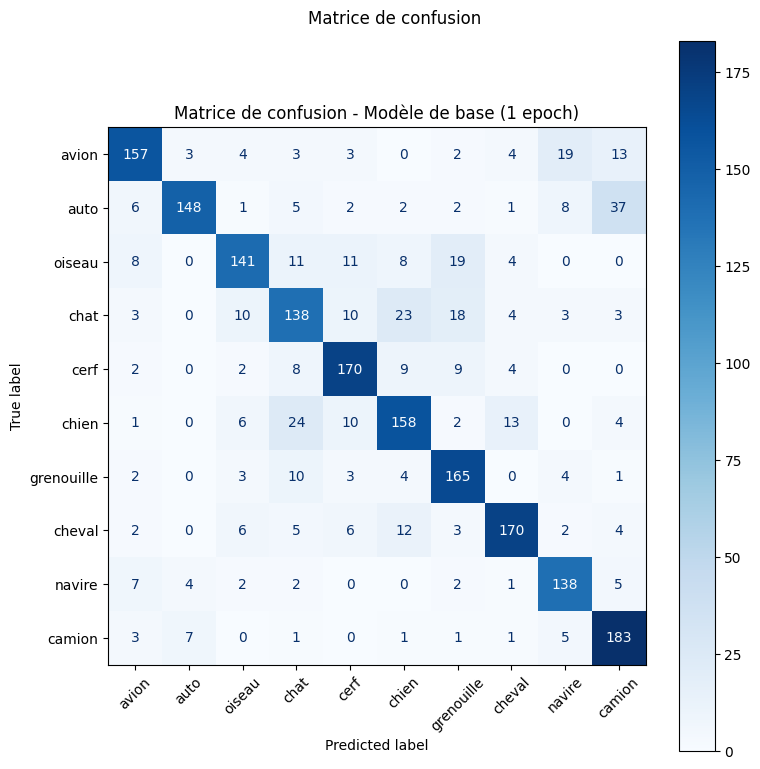

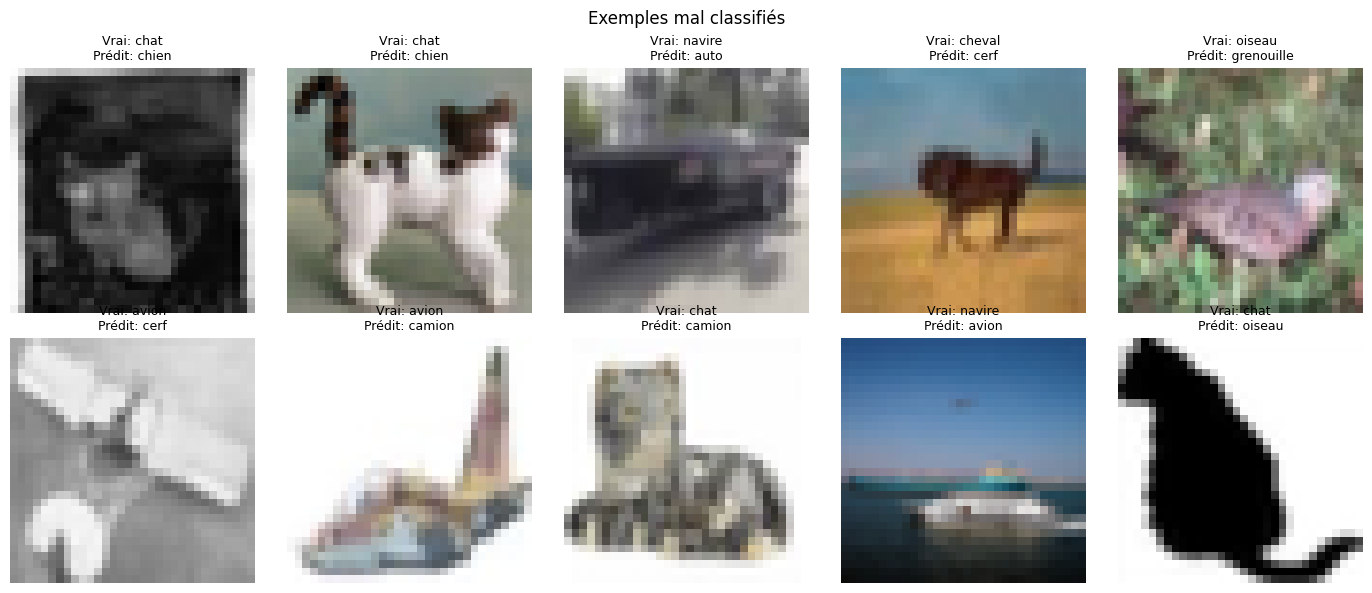

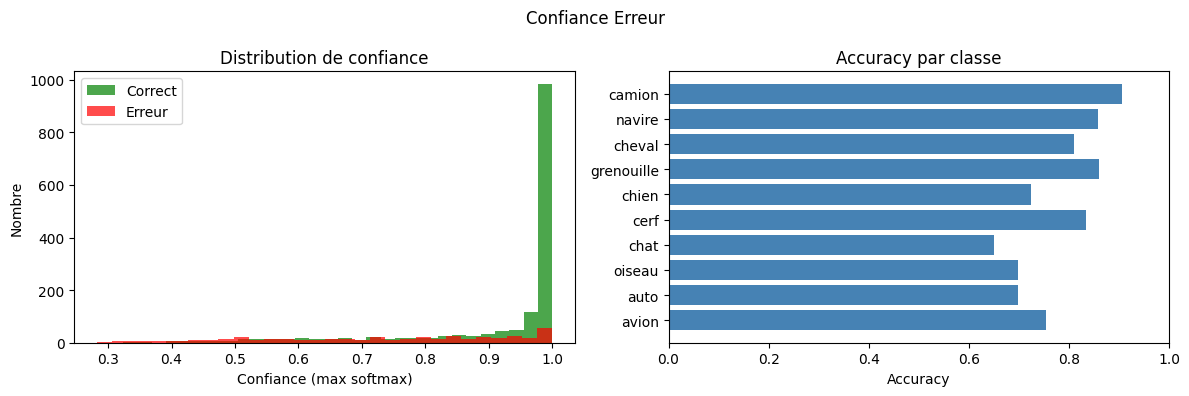

9965

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
  22/1563 [..............................] - ETA: 3s - loss: 2.5950 - accuracy: 0.1747   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 5s 3ms/step - loss: 1.5176 - accuracy: 0.4737 - val_loss: 1.1625 - val_accuracy: 0.5986 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 4s 2ms/step - loss: 1.0754 - accuracy: 0.6366 - val_loss: 0.8606 - val_accuracy: 0.7108 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.9196 - accuracy: 0.6964 - val_loss: 0.7496 - val_accuracy: 0.7540 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.8364 - accuracy: 0.7285 - val_loss: 0.7092 - val_accuracy: 0.7705 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 0.7666 - accuracy: 0.7504 - val_loss: 0.7264 - val_accuracy: 0.7684 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 0.7163 - accuracy: 0.7687 - val_loss: 0.6836 - val_accuracy: 0.7812 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/

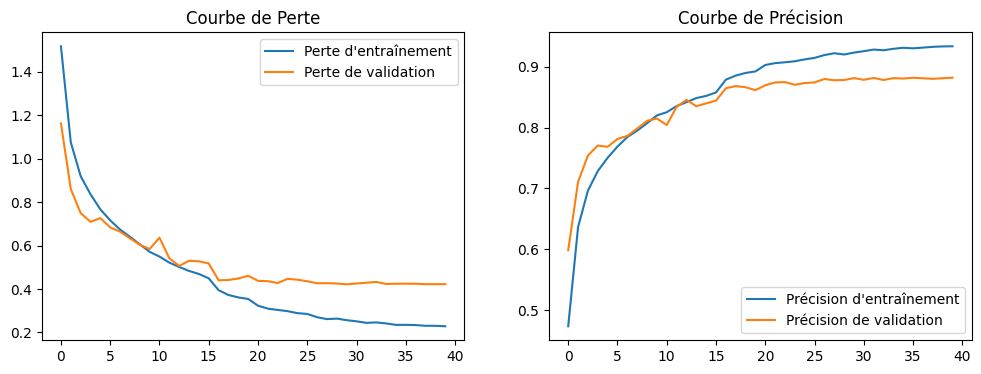

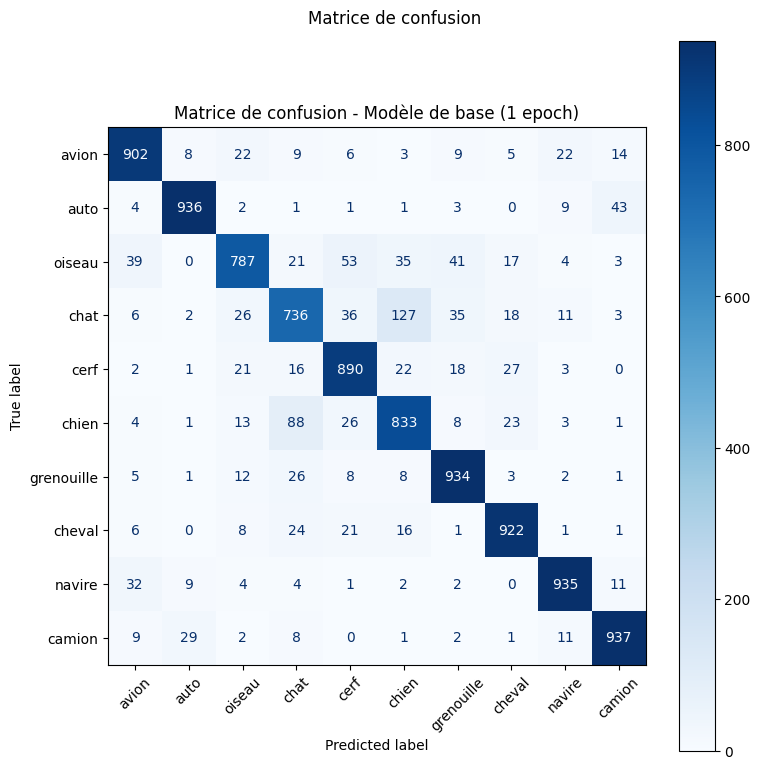

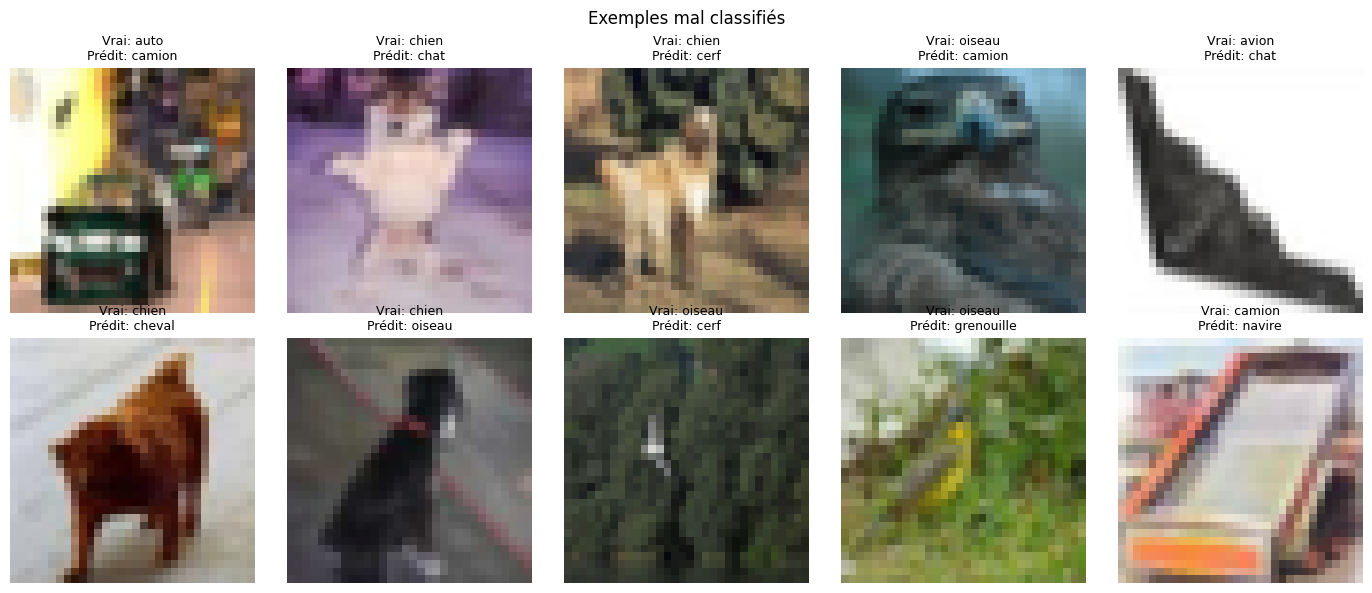

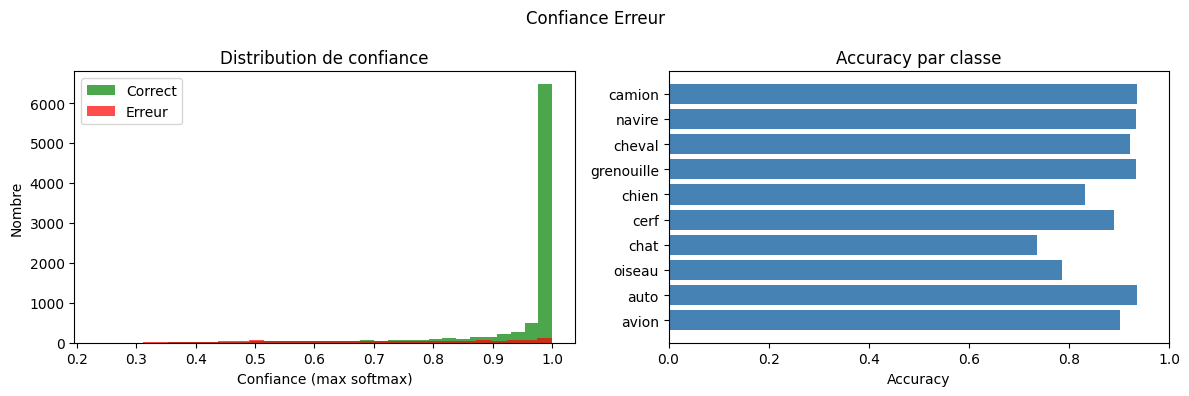

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8327 - accuracy: 0.7754 - 143ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7754
64/64 [==============================] - 0s 665us/step


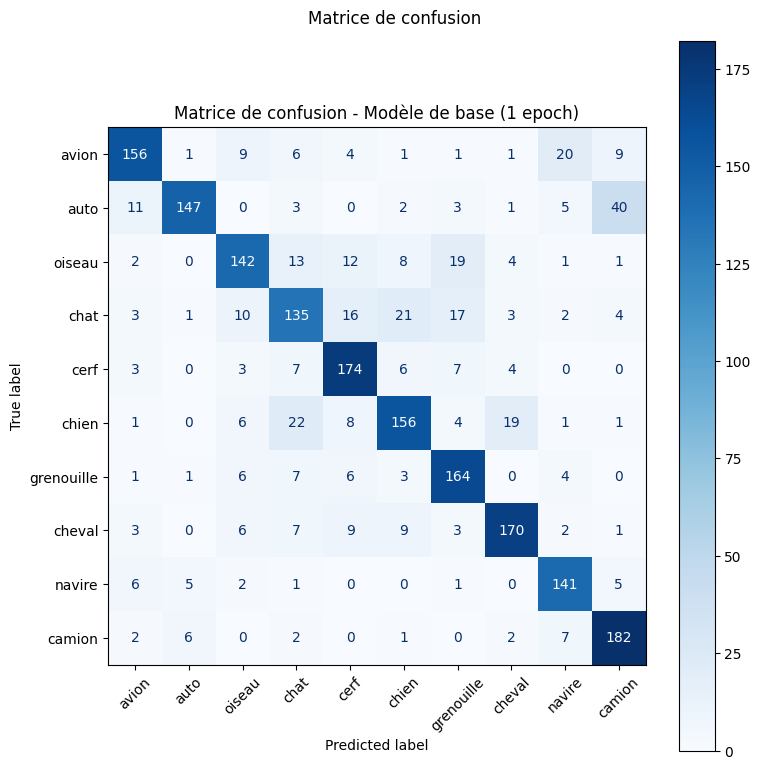

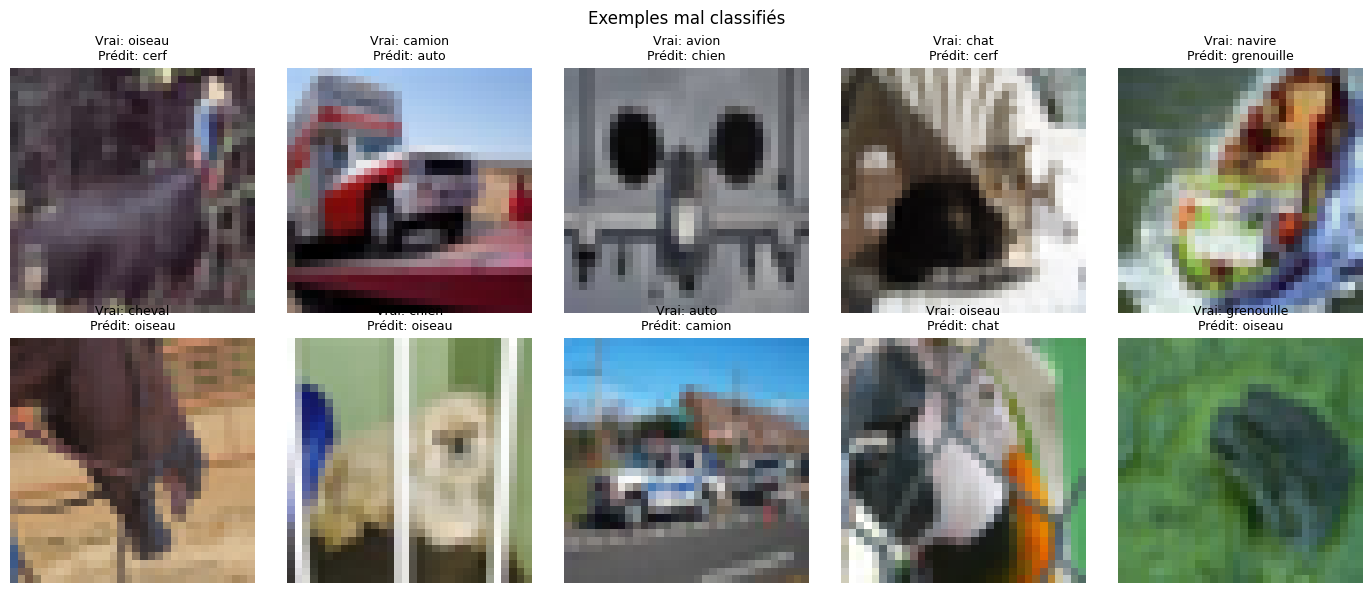

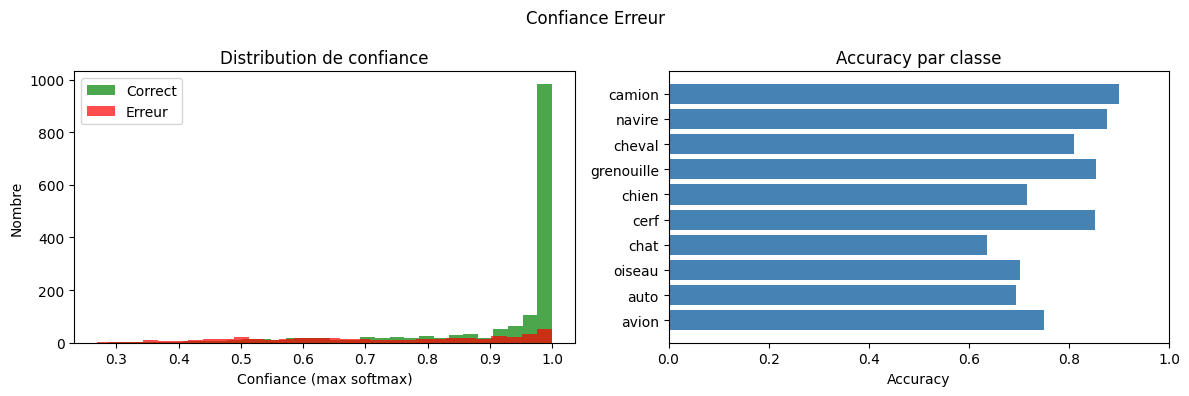

98393

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 21:40 - loss: 2.6785 - accuracy: 0.1250

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 7s 4ms/step - loss: 1.7366 - accuracy: 0.3828 - val_loss: 1.7500 - val_accuracy: 0.4301 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.3782 - accuracy: 0.5202 - val_loss: 1.3094 - val_accuracy: 0.5572 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.2134 - accuracy: 0.5857 - val_loss: 1.1058 - val_accuracy: 0.6221 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.1036 - accuracy: 0.6263 - val_loss: 0.9804 - val_accuracy: 0.6743 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.0338 - accuracy: 0.6556 - val_loss: 0.9878 - val_accuracy: 0.6751 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.9882 - accuracy: 0.6717 - val_loss: 0.8960 - val_accuracy: 0.6992 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 6s 4ms/

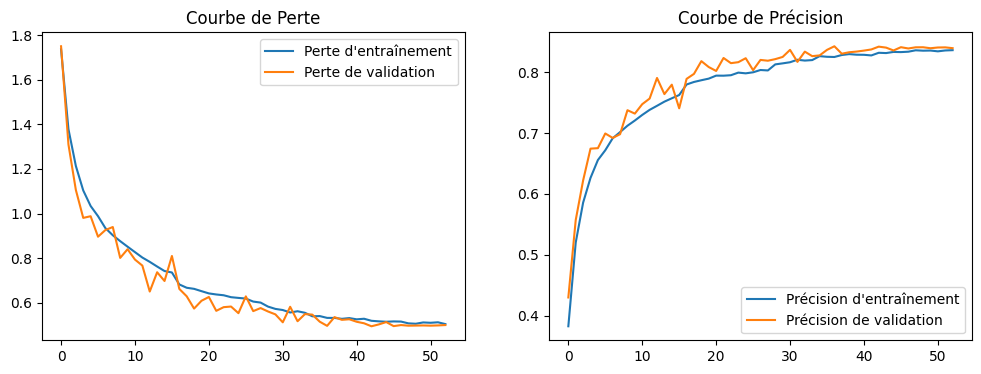

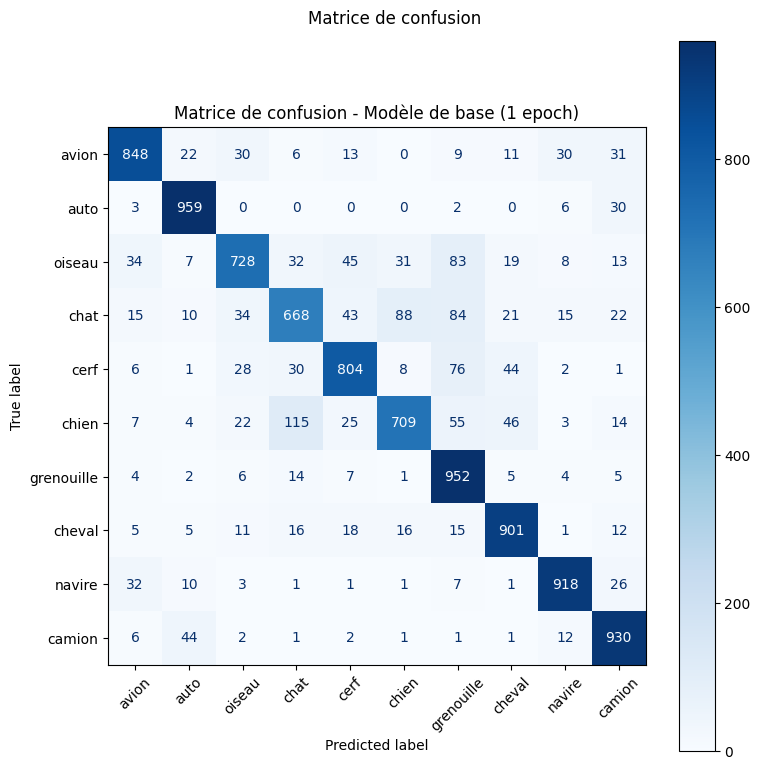

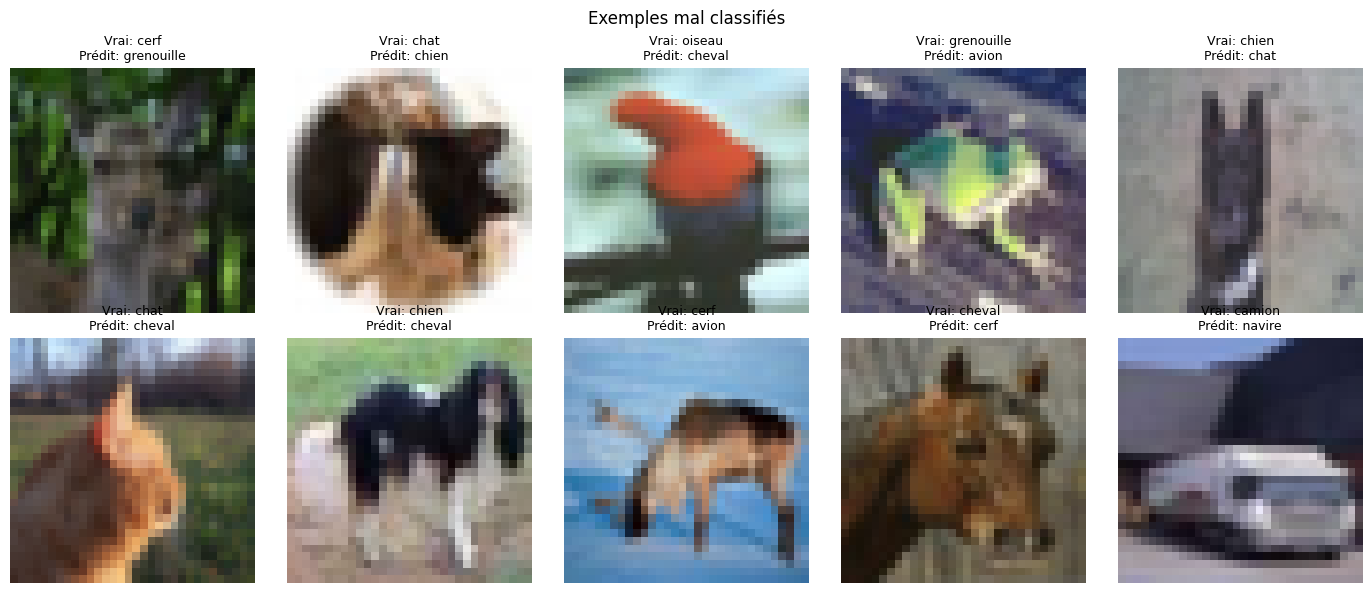

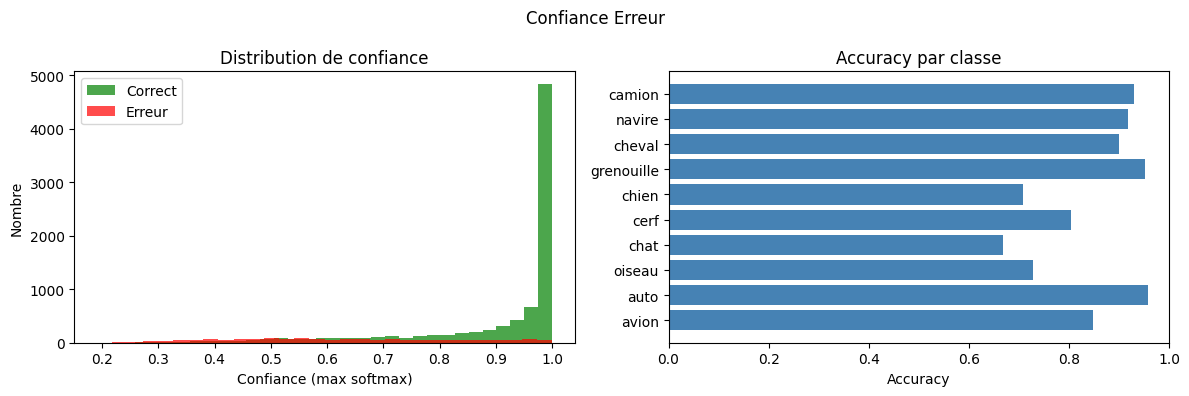

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.8315 - accuracy: 0.7348 - 144ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7348
64/64 [==============================] - 0s 671us/step


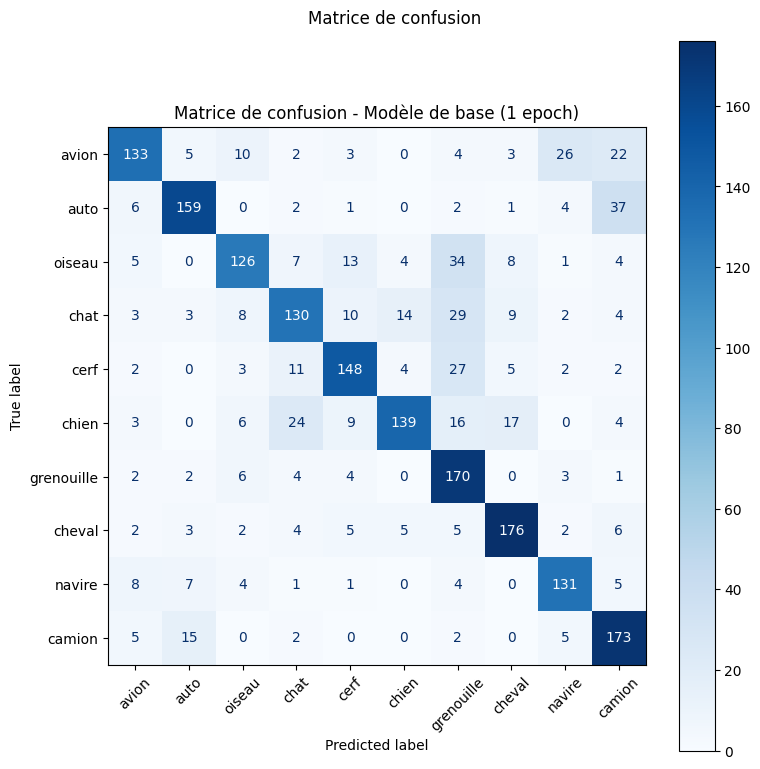

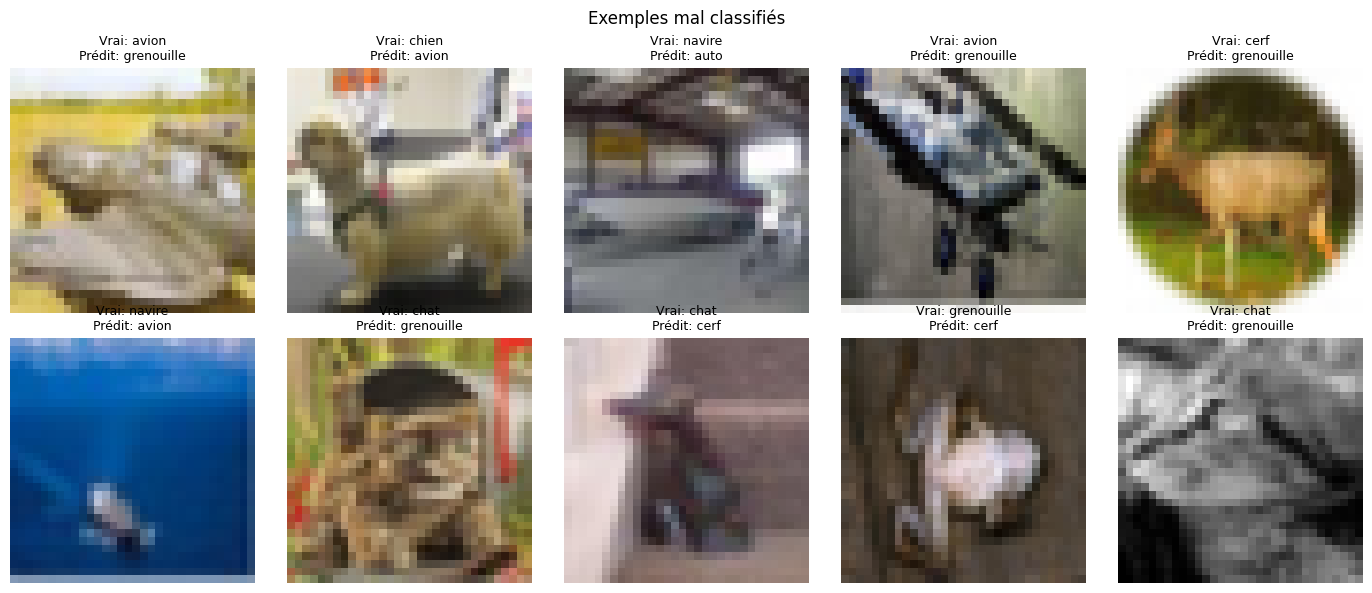

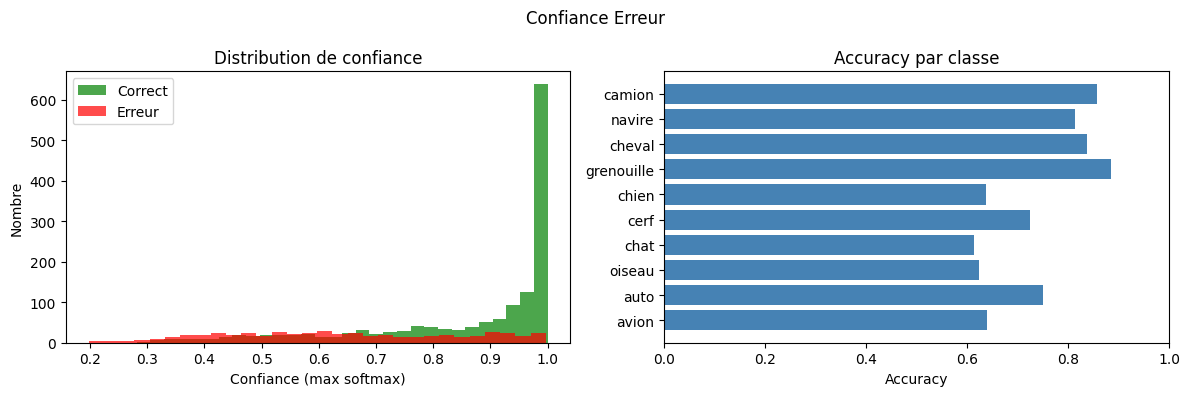

98363

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - augmentation de données


model = keras.Sequential([
    # Augmentation de données
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),


    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)


print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)

confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
  25/1563 [..............................] - ETA: 3s - loss: 2.5915 - accuracy: 0.1600   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.6221 - accuracy: 0.4312 - val_loss: 1.2789 - val_accuracy: 0.5595 - lr: 0.0100
Epoch 2/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.2184 - accuracy: 0.5852 - val_loss: 1.3083 - val_accuracy: 0.5905 - lr: 0.0100
Epoch 3/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.0601 - accuracy: 0.6432 - val_loss: 0.9193 - val_accuracy: 0.6876 - lr: 0.0100
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9587 - accuracy: 0.6840 - val_loss: 0.7665 - val_accuracy: 0.7486 - lr: 0.0100
Epoch 5/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8966 - accuracy: 0.7057 - val_loss: 0.7510 - val_accuracy: 0.7566 - lr: 0.0100
Epoch 6/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8443 - accuracy: 0.7233 - val_loss: 0.7932 - val_accuracy: 0.7477 - lr: 0.0100
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

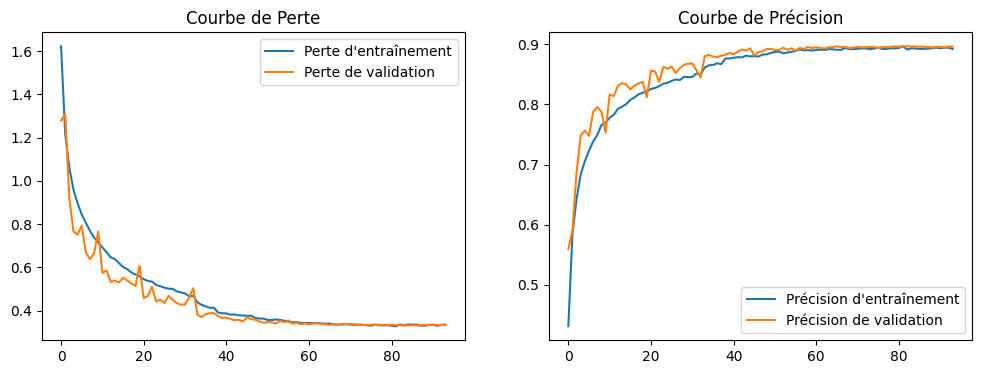

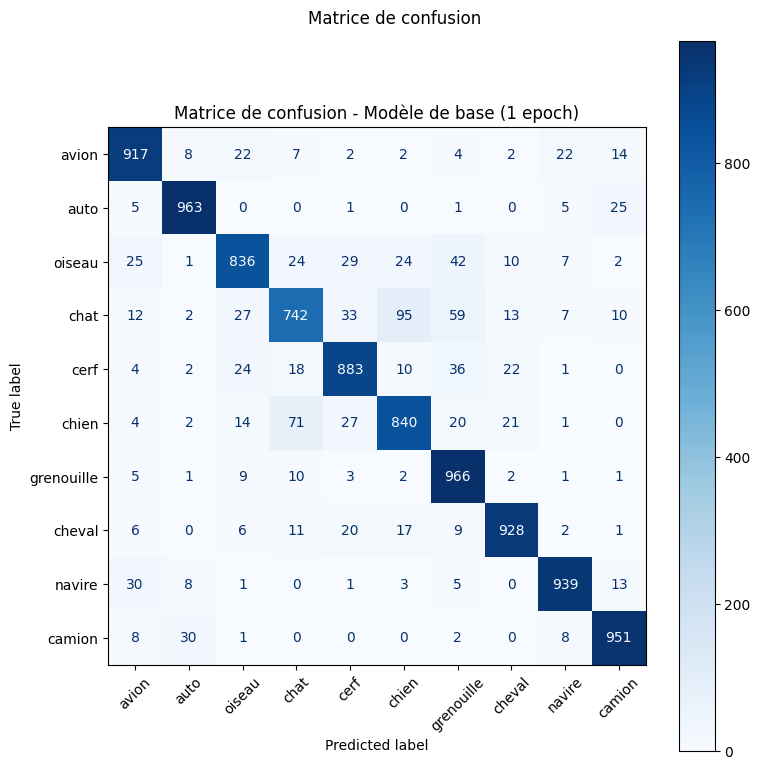

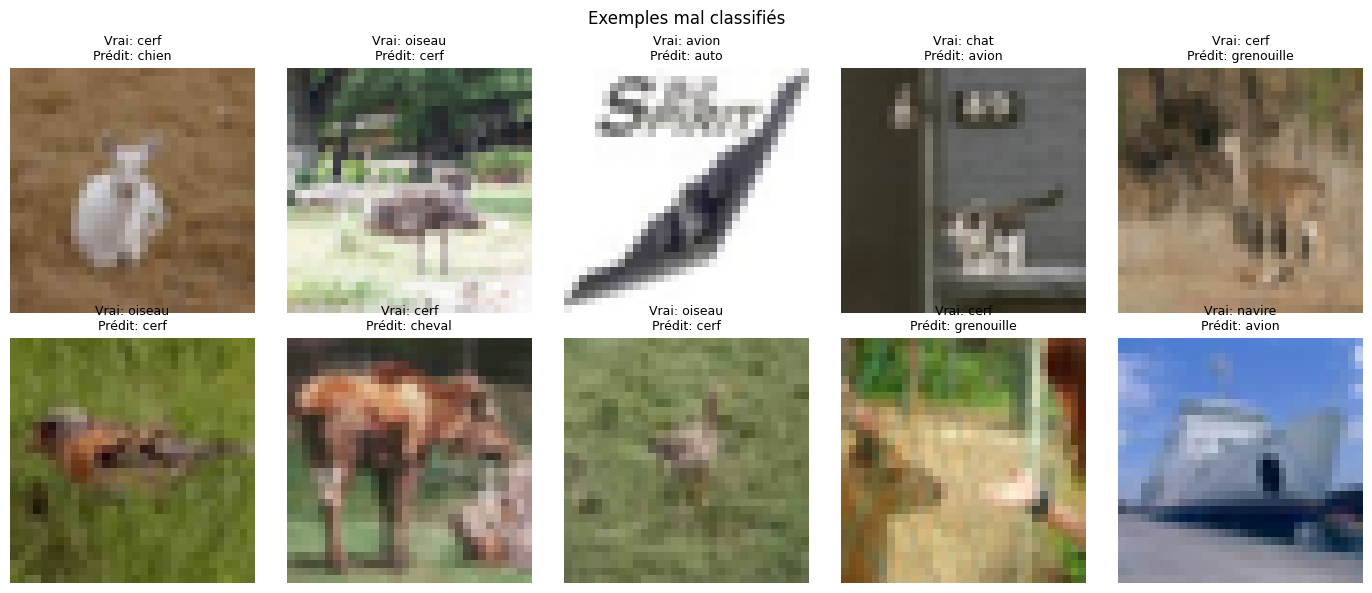

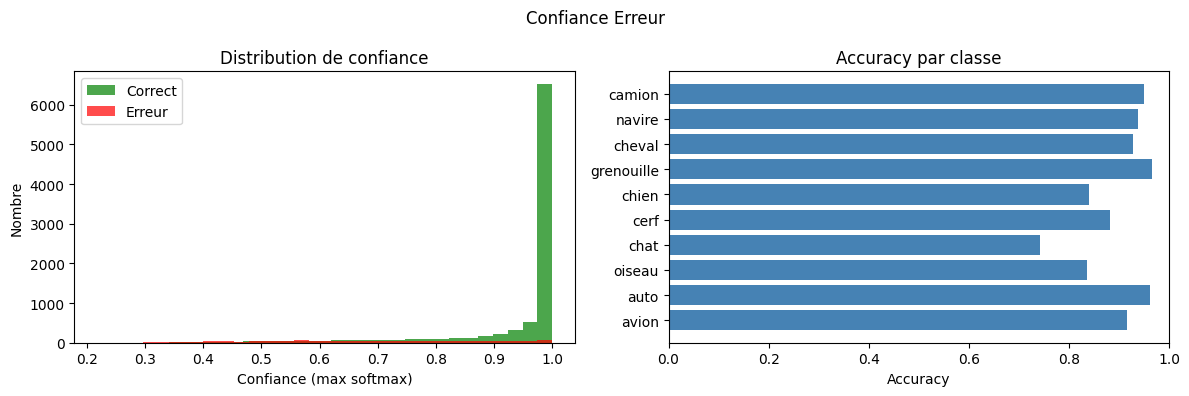

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6425 - accuracy: 0.8070 - 120ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.8070
64/64 [==============================] - 0s 525us/step


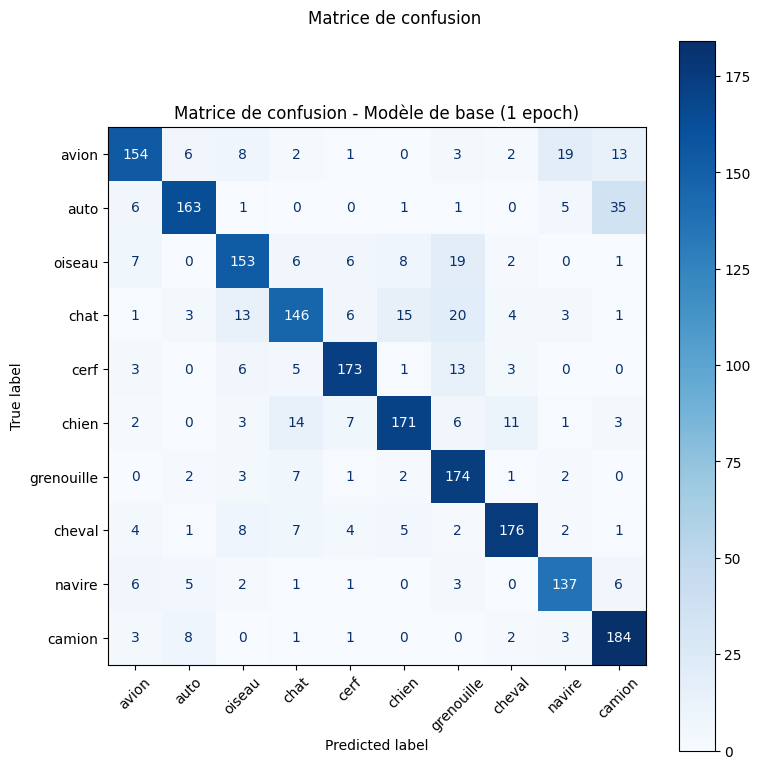

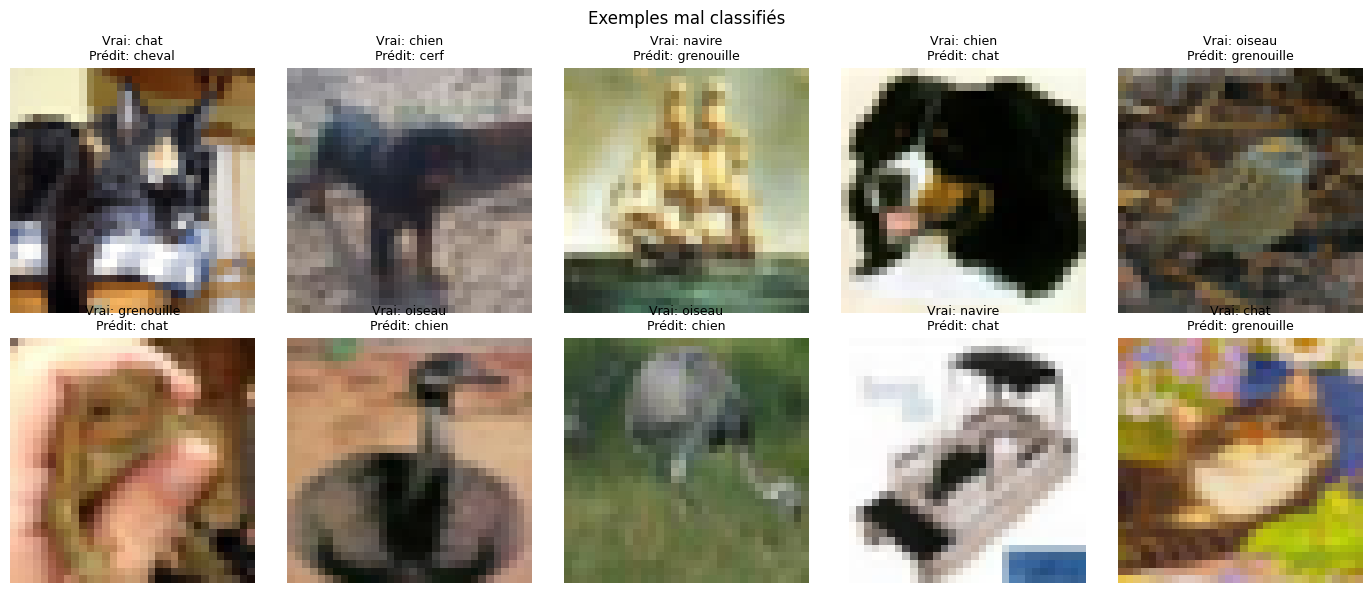

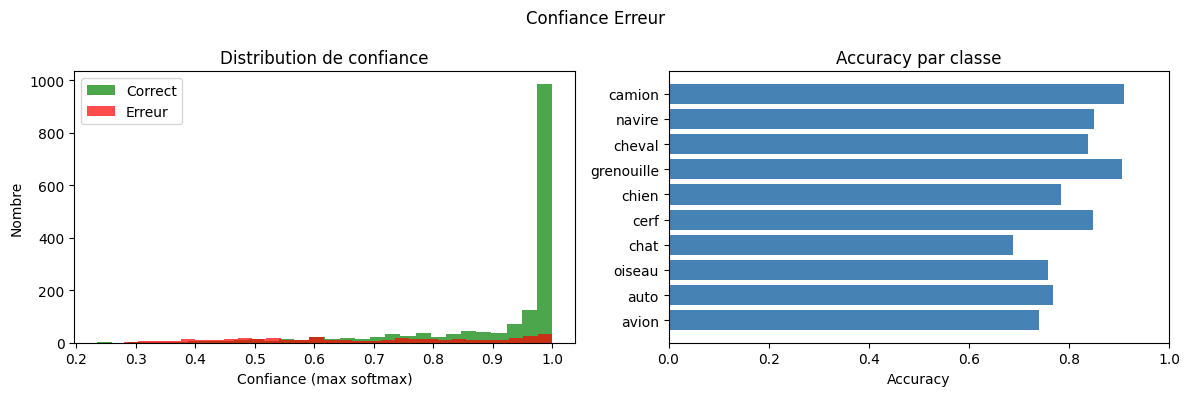

99661

In [11]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), 
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
   1/1563 [..............................] - ETA: 17:25 - loss: 2.8293 - accuracy: 0.0625

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.5610 - accuracy: 0.4317 - val_loss: 1.1946 - val_accuracy: 0.5731 - lr: 0.0100
Epoch 2/200
1563/1563 [==============================] - 4s 2ms/step - loss: 1.2151 - accuracy: 0.5678 - val_loss: 1.2996 - val_accuracy: 0.5613 - lr: 0.0100
Epoch 3/200
1563/1563 [==============================] - 4s 2ms/step - loss: 1.0664 - accuracy: 0.6252 - val_loss: 1.1211 - val_accuracy: 0.6220 - lr: 0.0100
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9751 - accuracy: 0.6629 - val_loss: 0.9524 - val_accuracy: 0.6750 - lr: 0.0100
Epoch 5/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9046 - accuracy: 0.6897 - val_loss: 0.9581 - val_accuracy: 0.6789 - lr: 0.0100
Epoch 6/200
1563/1563 [==============================] - 4s 2ms/step - loss: 0.8520 - accuracy: 0.7108 - val_loss: 0.7617 - val_accuracy: 0.7378 - lr: 0.0100
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

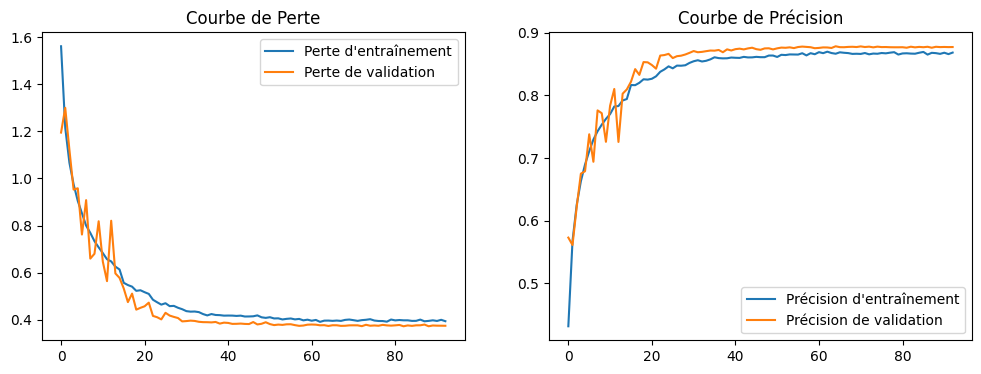

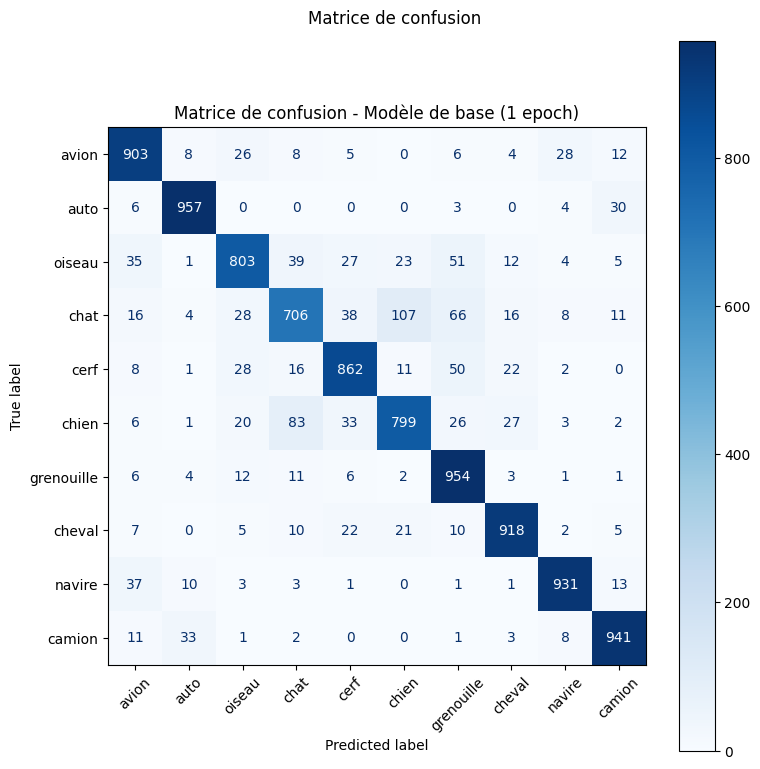

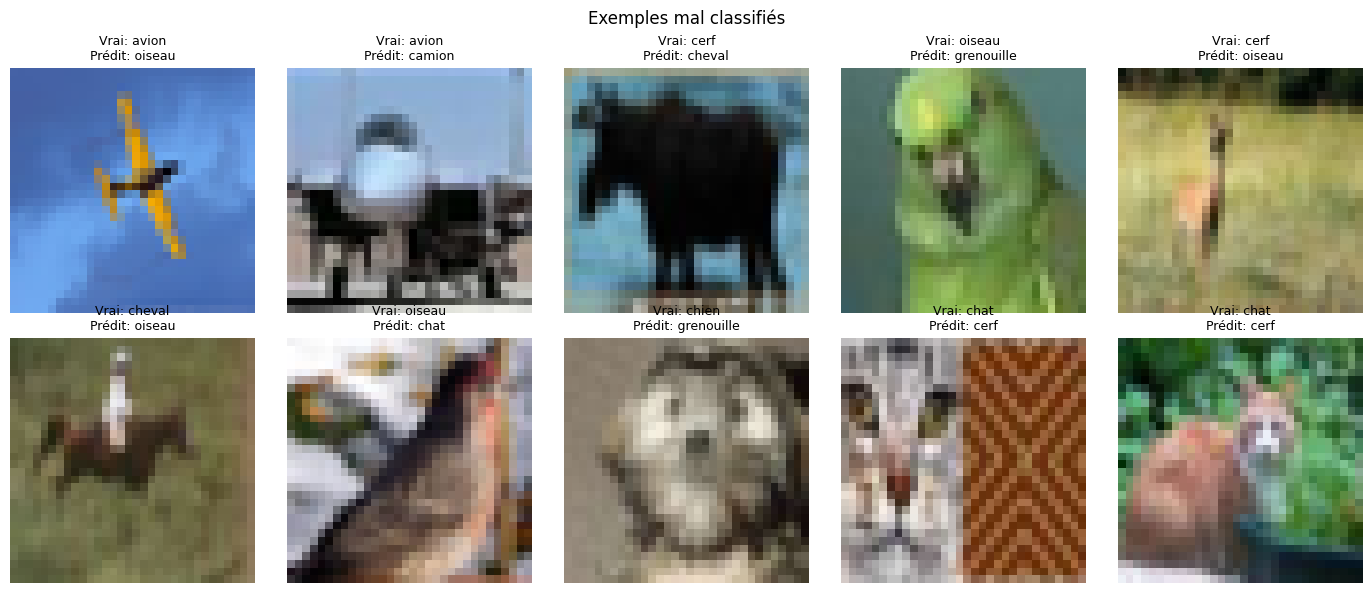

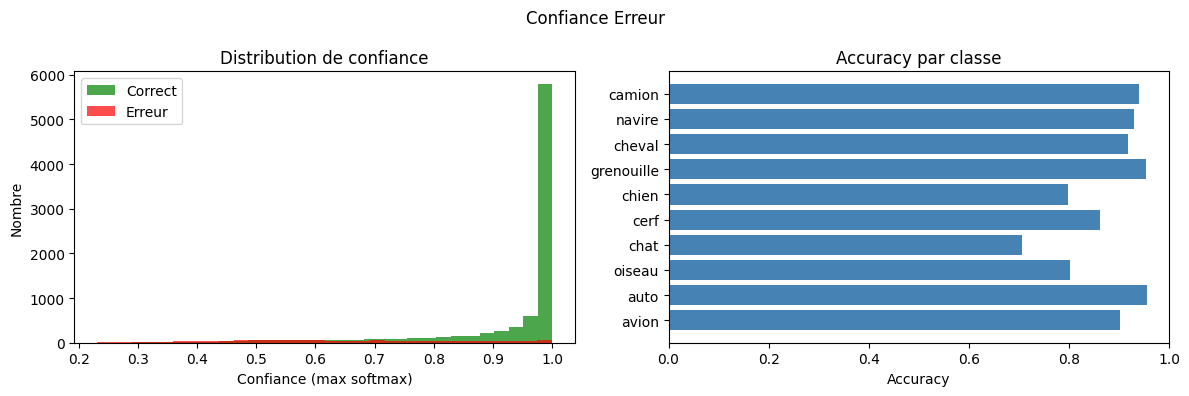

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6660 - accuracy: 0.7823 - 117ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7823
64/64 [==============================] - 0s 517us/step


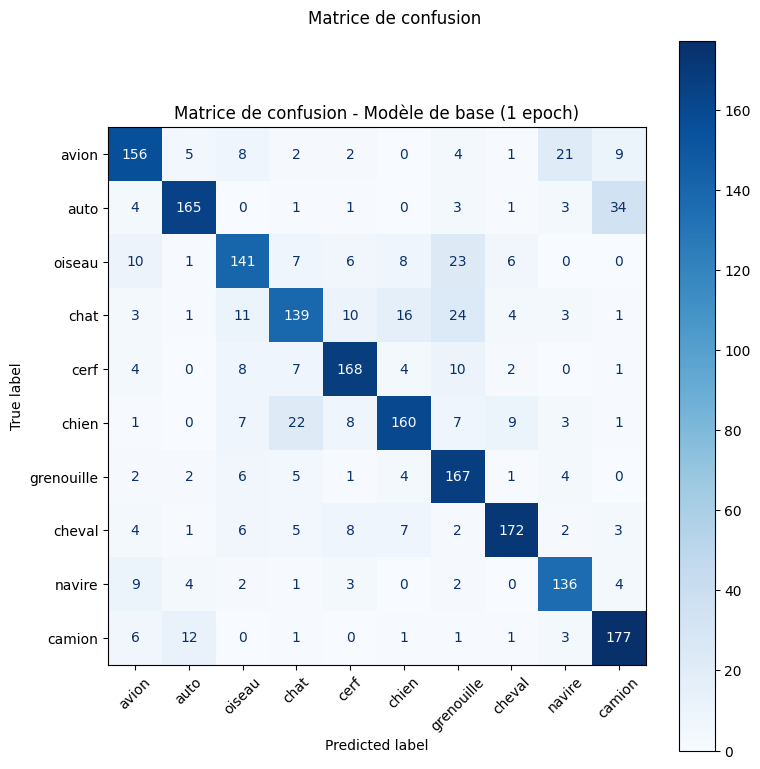

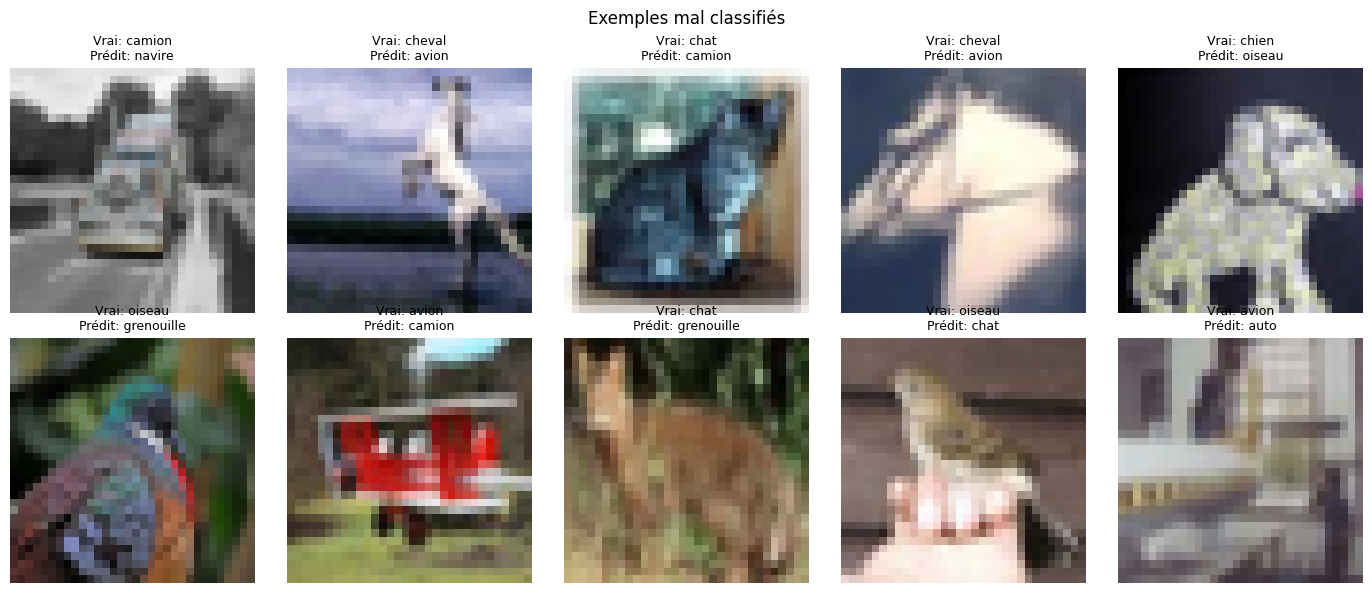

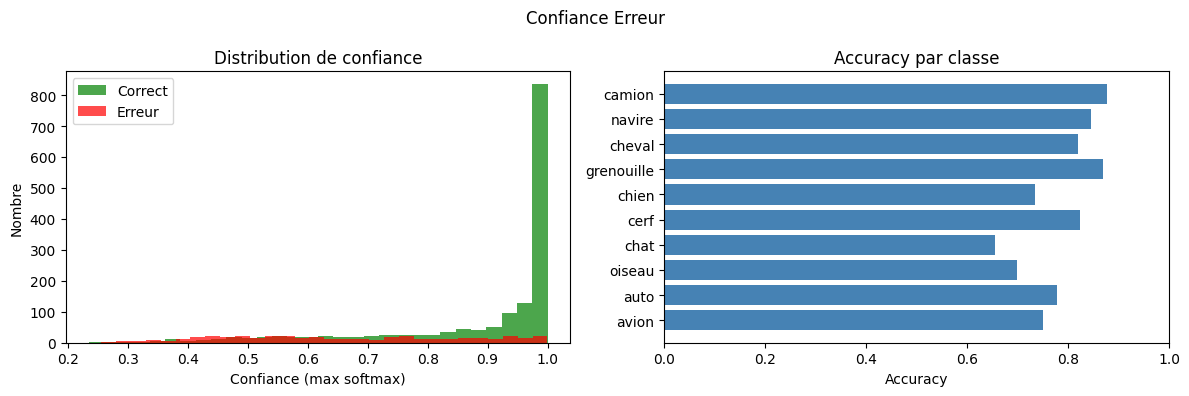

98564

In [12]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal
# - GlobalAveragePooling2D
# - dense avec 128 neurones


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/200
  25/1563 [..............................] - ETA: 3s - loss: 2.4621 - accuracy: 0.1462   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 4s 2ms/step - loss: 1.5836 - accuracy: 0.4207 - val_loss: 1.3461 - val_accuracy: 0.5206 - lr: 0.0200
Epoch 2/200
1563/1563 [==============================] - 3s 2ms/step - loss: 1.1986 - accuracy: 0.5747 - val_loss: 1.3220 - val_accuracy: 0.5525 - lr: 0.0200
Epoch 3/200
1563/1563 [==============================] - 4s 2ms/step - loss: 1.0369 - accuracy: 0.6413 - val_loss: 1.0178 - val_accuracy: 0.6530 - lr: 0.0200
Epoch 4/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.9357 - accuracy: 0.6775 - val_loss: 0.8275 - val_accuracy: 0.7139 - lr: 0.0200
Epoch 5/200
1563/1563 [==============================] - 4s 2ms/step - loss: 0.8615 - accuracy: 0.7051 - val_loss: 0.7559 - val_accuracy: 0.7370 - lr: 0.0200
Epoch 6/200
1563/1563 [==============================] - 3s 2ms/step - loss: 0.8050 - accuracy: 0.7257 - val_loss: 0.6880 - val_accuracy: 0.7660 - lr: 0.0200
Epoch 7/200
1563/1563 [==============================] - 3s 2ms/

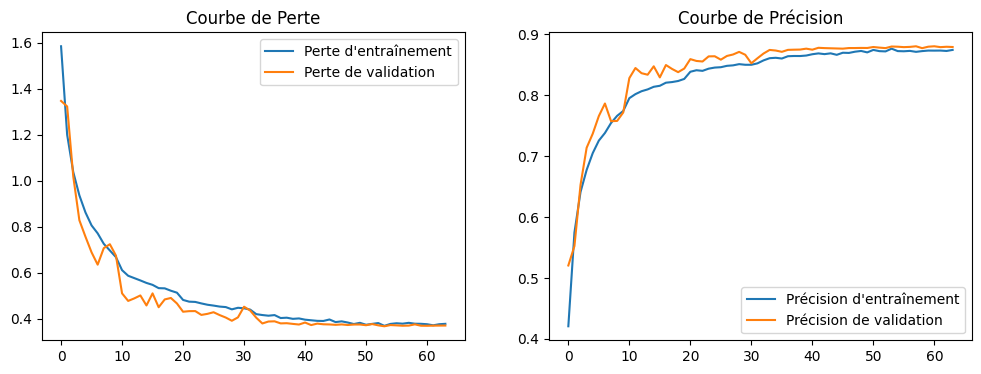

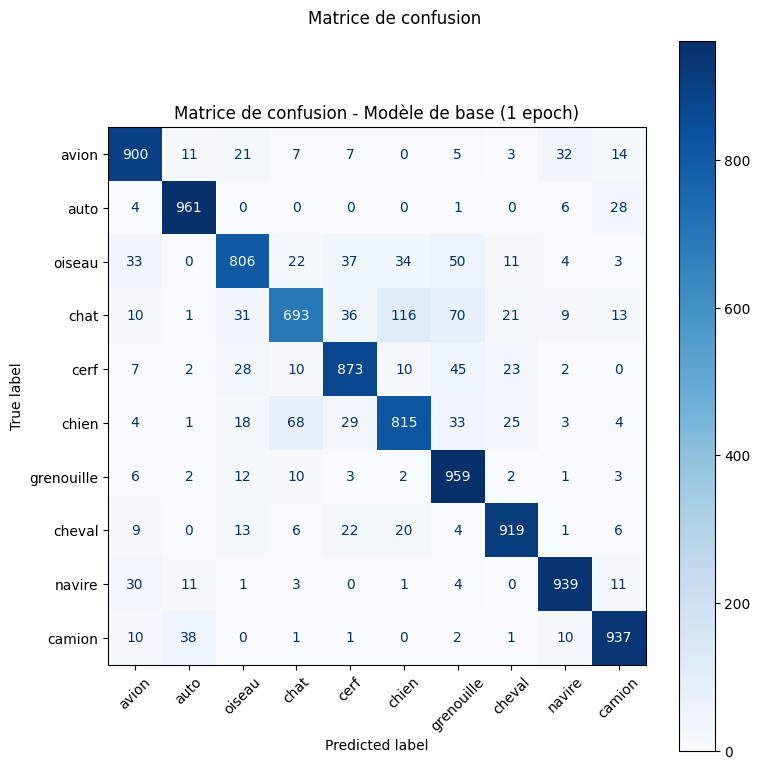

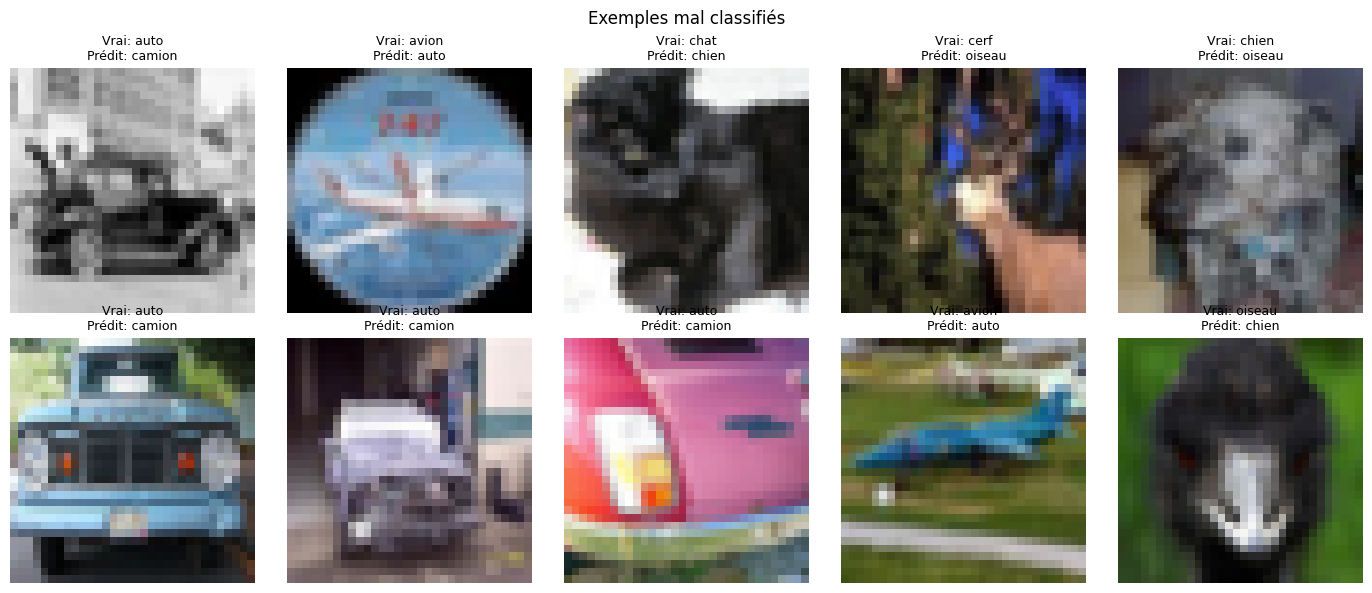

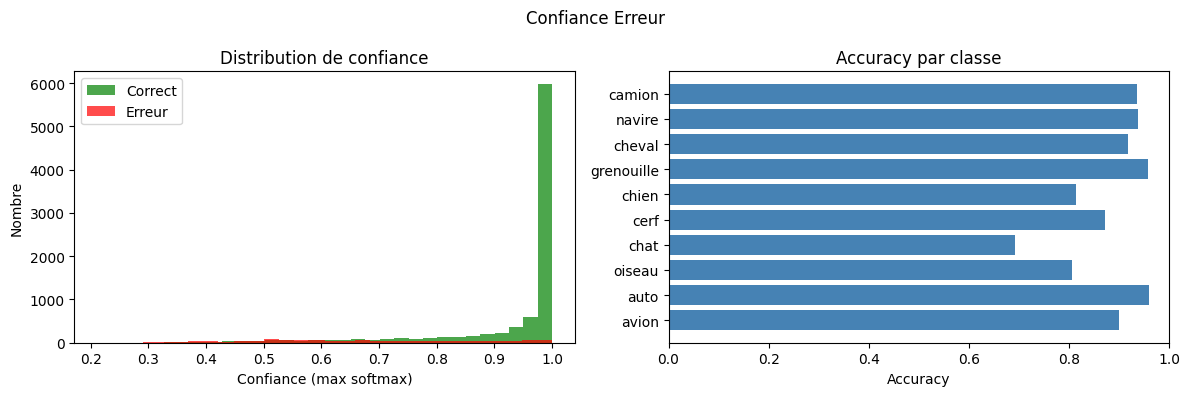

###########################################################CIFAR10_1 Validation###########################################################
64/64 - 0s - loss: 0.6777 - accuracy: 0.7838 - 117ms/epoch - 2ms/step
Précision sur CIFAR-10.1 (validation externe) : 0.7838
64/64 [==============================] - 0s 531us/step


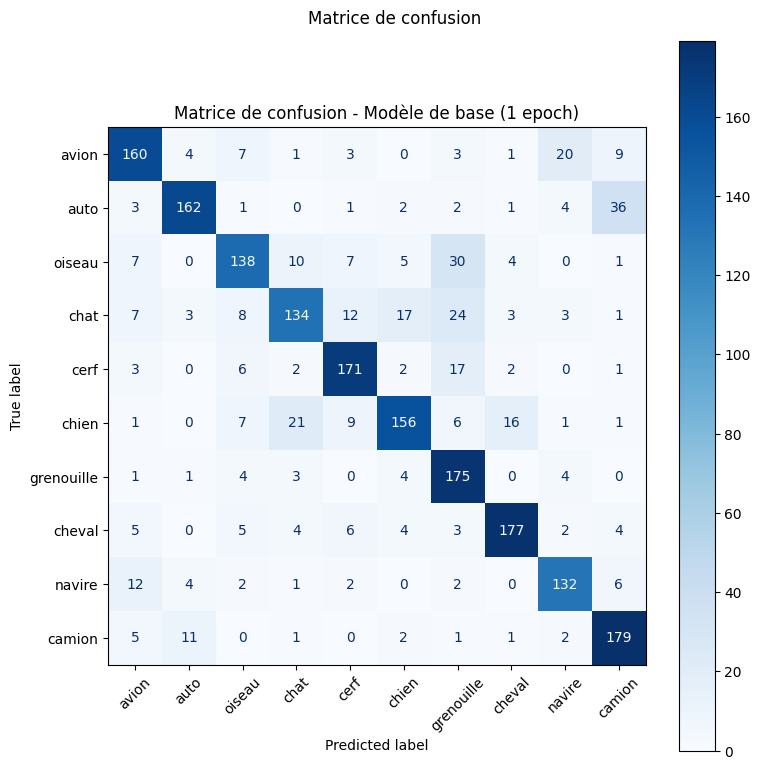

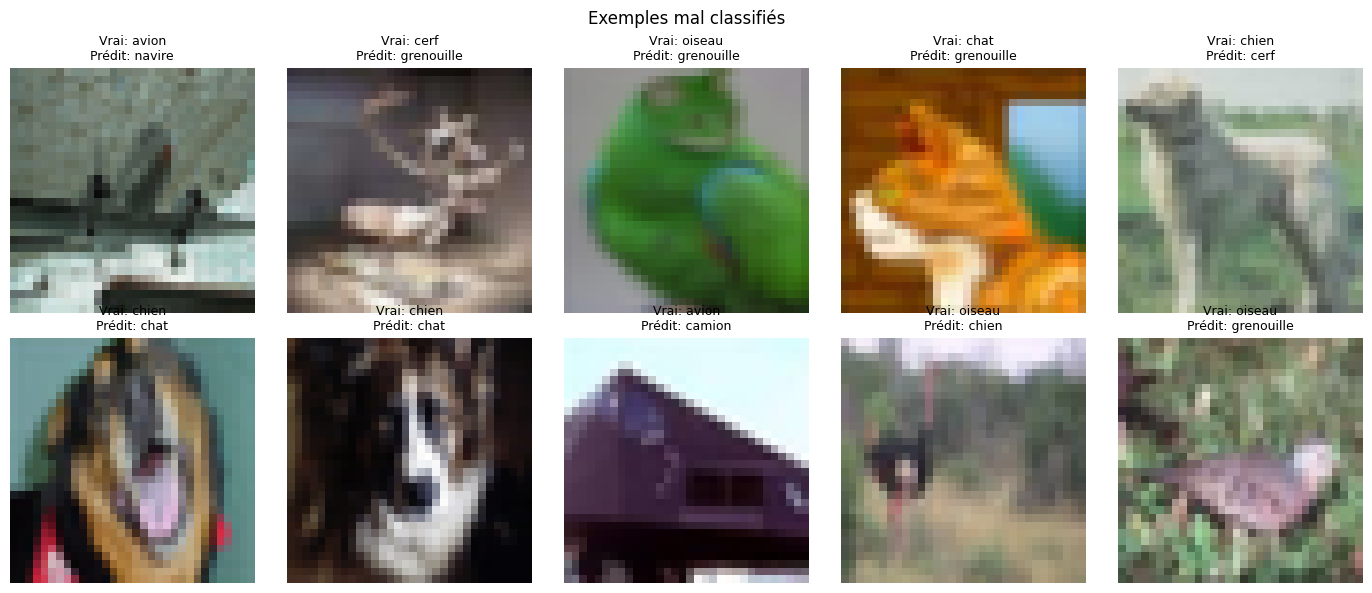

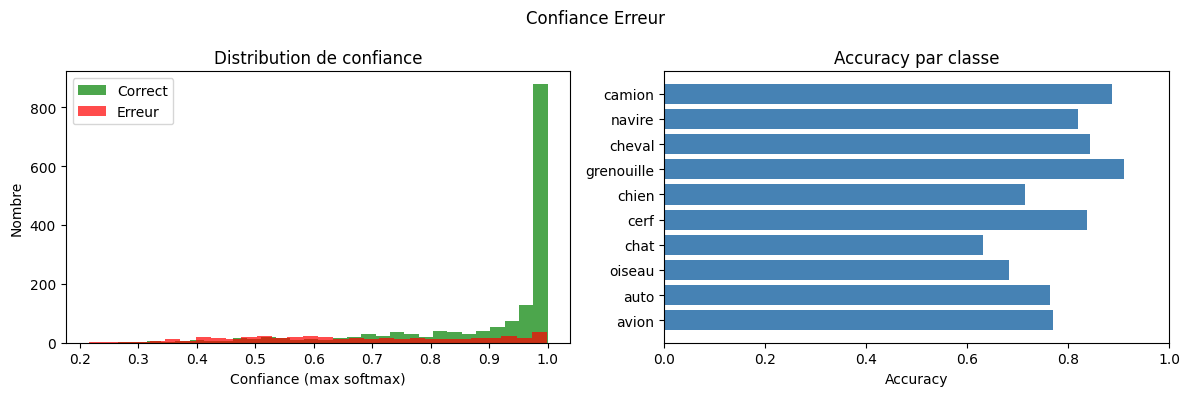

98698

In [13]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(1e-4)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau
# - Cell 13 avec validation CIFAR-10.1
# - test avec 200 époques 
# - augmentation de données minimal
# - GlobalAveragePooling2D
# - dense avec 128 neurones
# - learning_rate=0.02
# - kernel_regularizer=keras.regularizers.l2(5e-5)


model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(), 
    layers.Dense(128, kernel_regularizer=keras.regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.02, momentum=0.9, nesterov=True),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)

print("###########################################################"
      "CIFAR10_1 Validation"
      "###########################################################"
)

ext_loss, ext_acc = model.evaluate(x_ext, y_ext, verbose=2)
print(f'Précision sur CIFAR-10.1 (validation externe) : {ext_acc:.4f}')
y_pred_ext = model.predict(x_ext).argmax(axis=1)
y_proba_ext = model.predict(x_ext)
confusion_matrices(y_pred_ext, y_ext)
classification_error_samples(y_pred_ext, x_ext, y_ext)
error_confidence(y_proba_ext, y_pred_ext, y_ext)


del y_proba, y_pred, history_fit, model
gc.collect()